In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing
import os

import lightgbm as lgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import optuna
import shap
shap.initjs()

/Users/akhilantony/miniconda3/envs/datascience/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
project_path ="/Volumes/Work/datascience/data science/projects/"

In [3]:
df_data = pd.read_csv(project_path+"store-sales-time-series-forecasting/store_sales_time_series.csv")

/var/folders/jm/7vmlf0cj3hqfx63tjv7bwkzr0000gn/T/ipykernel_87079/1026169433.py:1: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_data = pd.read_csv(project_path+"store-sales-time-series-forecasting/store_sales_time_series.csv")


In [4]:
df_data.head(10)

,store_nbr,family,sales,onpromotion,type,holiday,locale,oil_price,oilprice_linear,oilprice_spline,pay_day,day_sin,day_cos,month_sin,month_cos,days_since_start
0,1,AUTOMOTIVE,0.0,0,D,NaN,NaN,NaN,93.14,93.14,0,0.201299,0.97953,0.5,0.866025,0
1,1,BABY CARE,0.0,0,D,NaN,NaN,NaN,93.14,93.14,0,0.201299,0.97953,0.5,0.866025,0
2,1,BEAUTY,0.0,0,D,NaN,NaN,NaN,93.14,93.14,0,0.201299,0.97953,0.5,0.866025,0
3,1,BEVERAGES,0.0,0,D,NaN,NaN,NaN,93.14,93.14,0,0.201299,0.97953,0.5,0.866025,0
4,1,BOOKS,0.0,0,D,NaN,NaN,NaN,93.14,93.14,0,0.201299,0.97953,0.5,0.866025,0
5,1,BREAD/BAKERY,0.0,0,D,NaN,NaN,NaN,93.14,93.14,0,0.201299,0.97953,0.5,0.866025,0
6,1,CELEBRATION,0.0,0,D,NaN,NaN,NaN,93.14,93.14,0,0.201299,0.97953,0.5,0.866025,0
7,1,CLEANING,0.0,0,D,NaN,NaN,NaN,93.14,93.14,0,0.201299,0.97953,0.5,0.866025,0
8,1,DAIRY,0.0,0,D,NaN,NaN,NaN,93.14,93.14,0,0.201299,0.97953,0.5,0.866025,0
9,1,DELI,0.0,0,D,NaN,NaN,NaN,93.14,93.14,0,0.201299,0.97953,0.5,0.866025,0


In [5]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3001152 entries, 0 to 3001151
Data columns (total 16 columns):
 #   Column            Dtype  
---  ------            -----  
 0   store_nbr         int64  
 1   family            object 
 2   sales             float64
 3   onpromotion       int64  
 4   type              object 
 5   holiday           object 
 6   locale            object 
 7   oil_price         float64
 8   oilprice_linear   float64
 9   oilprice_spline   float64
 10  pay_day           int64  
 11  day_sin           float64
 12  day_cos           float64
 13  month_sin         float64
 14  month_cos         float64
 15  days_since_start  int64  
dtypes: float64(8), int64(4), object(4)
memory usage: 366.4+ MB


We have 14 feature columns with a mixture of numerical and categorical data and around 3 million rows. Sales is a continuous variable, therefore we have a regression in hand.

Lets build a LightGBM regressor as the baseline model.
Why LightGBM?
- Handles large datasets effeciently
- Native handling of ctegorical variables ( no need for one-hot encoding)
- can model non-linear relationships and interactions between features, promotion, holidays with sales.
- suport early stopping for fast experimentation

## LightGBM

In [6]:
df_lgb = df_data.copy(deep=True)
target = 'sales'

# features to drop

drop_cols = [
    target,
    "oilprice_spline",
    "oilprice_linear"
]

# define categorical columns

categorical_feat = [
    "store_nbr","family","type","holiday","locale"
]

for col in categorical_feat:
    df_lgb[col] = df_lgb[col].astype("category")

max_day = df_lgb["days_since_start"].max()
val_set_start = max_day - 60

# Train and validation split
df_train_lgb = df_lgb[df_lgb["days_since_start"] <= val_set_start]
df_val_lgb = df_lgb[df_lgb["days_since_start"] > val_set_start]

X_train = df_train_lgb.drop(columns=drop_cols)
Y_train = df_train_lgb[target]
X_val = df_val_lgb.drop(columns=drop_cols)
Y_val = df_val_lgb[target]



In [7]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2894232 entries, 0 to 2894231
Data columns (total 13 columns):
 #   Column            Dtype   
---  ------            -----   
 0   store_nbr         category
 1   family            category
 2   onpromotion       int64   
 3   type              category
 4   holiday           category
 5   locale            category
 6   oil_price         float64 
 7   pay_day           int64   
 8   day_sin           float64 
 9   day_cos           float64 
 10  month_sin         float64 
 11  month_cos         float64 
 12  days_since_start  int64   
dtypes: category(5), float64(5), int64(3)
memory usage: 212.5 MB


In [8]:
# Create LightGBM. dataset

lgb_train = lgb.Dataset(X_train, label=Y_train, categorical_feature=categorical_feat)
lgb_val = lgb.Dataset(X_val,label=Y_val,categorical_feature=categorical_feat)

# LightGBM parameters

params = {
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves" : 64,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose":-1,
}

model = lgb.train(
    params,
    lgb_train,
    valid_sets = [lgb_train, lgb_val],
    valid_names=["train","val"],
    num_boost_round = 2000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=50)  # print every 50 rounds
    ]
)


Training until validation scores don't improve for 100 rounds
[50]	train's rmse: 345.816	val's rmse: 338.885
[100]	train's rmse: 288.105	val's rmse: 312.285
[150]	train's rmse: 266.928	val's rmse: 308.834
[200]	train's rmse: 255.08	val's rmse: 306.991
[250]	train's rmse: 248.137	val's rmse: 309.139
[300]	train's rmse: 241.96	val's rmse: 309.729
Early stopping, best iteration is:
[222]	train's rmse: 251.892	val's rmse: 306.524


Validation RMSE 303.6195


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

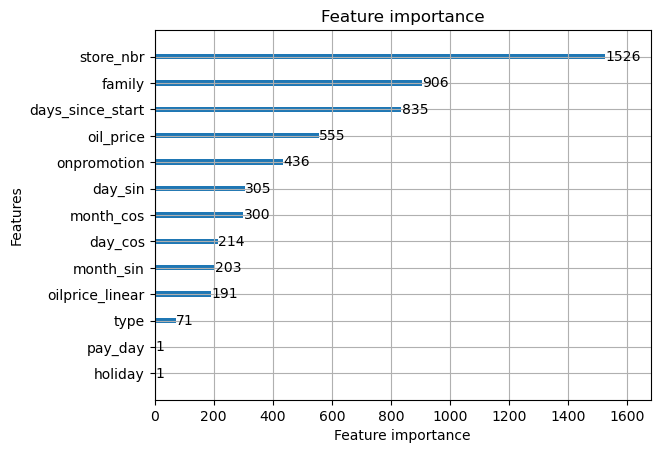

In [ ]:
### THis is using oilprice linear dont touch this 

# Evaluate

y_pred = model.predict(X_val,num_iteration=model.best_iteration)
rmse = np.sqrt(mean_squared_error(Y_val,y_pred))
print(f"Validation RMSE {rmse:.4f}")

#Feature importance
lgb.plot_importance(model,max_num_features=20)

Validation RMSE 306.5244
['store_nbr', 'family', 'onpromotion', 'type', 'holiday', 'locale', 'oil_price', 'pay_day', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'days_since_start']
[3604 2085 1271   83   23    1 1441   50 1070  712  638  723 2285]


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

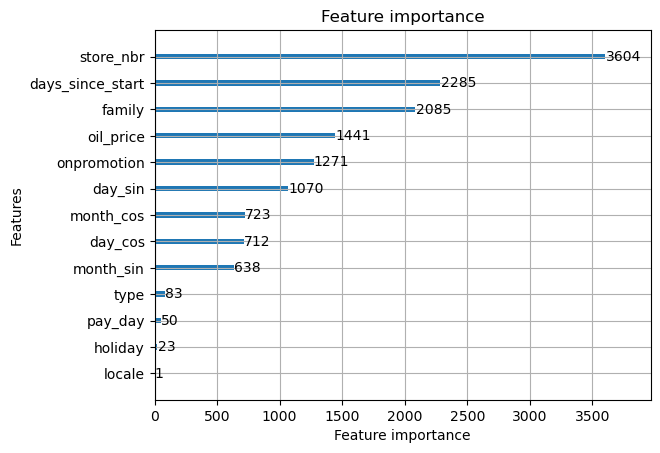

In [9]:
## This is using oil price.
# Evaluate

y_pred = model.predict(X_val,num_iteration=model.best_iteration)
rmse = np.sqrt(mean_squared_error(Y_val,y_pred))
print(f"Validation RMSE {rmse:.4f}")

#Feature importance
print(model.feature_name())
print(model.feature_importance())
lgb.plot_importance(model,max_num_features=20)

### Adding lag effects


In a time series analysis since our goal is to capture future trends, it is fair to assume i have the past sales data, in principle til the previous day.
Therefore lets add a new column which captures the sales of previous days

In [10]:
# Sorting for lag calculation
df_lgb_lag = df_lgb.sort_values(['store_nbr','family','days_since_start'])
new_features = []
# Lag features from previous sales
lag_window = [1,7,14]
for lag in lag_window:
    df_lgb_lag[f"sales_lag_{lag}"] = df_lgb_lag.groupby(['store_nbr','family'])['sales'].shift(lag)
    new_features.append(f"sales_lag_{lag}")

# Rolling mean features
rolling_window = [7,14,28]
for window in rolling_window:
    df_lgb_lag[f"sales_roll_mean_{window}"] = (
        df_lgb_lag.groupby(['store_nbr','family'])['sales']
        .shift(1)
        .rolling(window=window)
        .mean()
    )
    new_features.append(f"sales_roll_mean_{window}")

# Rolling std features
for window in rolling_window:
    df_lgb_lag[f"sales_roll_std_{window}"] = (
        df_lgb_lag.groupby(["store_nbr","family"])['sales']
        .shift(1)
        .rolling(window=window)
        .std()
    )
    new_features.append(f"sales_roll_std_{window}")

df_lgb_lag = df_lgb_lag.dropna(subset=new_features)

/var/folders/jm/7vmlf0cj3hqfx63tjv7bwkzr0000gn/T/ipykernel_87079/1727134597.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_lgb_lag[f"sales_lag_{lag}"] = df_lgb_lag.groupby(['store_nbr','family'])['sales'].shift(lag)
/var/folders/jm/7vmlf0cj3hqfx63tjv7bwkzr0000gn/T/ipykernel_87079/1727134597.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_lgb_lag[f"sales_lag_{lag}"] = df_lgb_lag.groupby(['store_nbr','family'])['sales'].shift(lag)
/var/folders/jm/7vmlf0cj3hqfx63tjv7bwkzr0000gn/T/ipykernel_87079/1727134597.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True

In [11]:
df_lgb_lag_train = df_lgb_lag[df_lgb_lag['days_since_start'] <= val_set_start]
df_lgb_lag_val = df_lgb_lag[df_lgb_lag["days_since_start"] > val_set_start]

X_train = df_lgb_lag_train.drop(columns=drop_cols)
y_train = df_lgb_lag_train[target]
X_val = df_lgb_lag_val.drop(columns=drop_cols)
y_val = df_lgb_lag_val[target]

lgb_lag_train = lgb.Dataset(X_train, label= y_train, categorical_feature=categorical_feat)
lgb_lag_val = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_feat)

model_lag = lgb.train(
    params,
    lgb_lag_train,
    valid_sets = [lgb_lag_train, lgb_lag_val],
    valid_names=["train","val"],
    num_boost_round = 2000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=50)  # print every 50 rounds
    ]
)

Training until validation scores don't improve for 100 rounds
[50]	train's rmse: 272.126	val's rmse: 241.696
[100]	train's rmse: 233.07	val's rmse: 232.455
[150]	train's rmse: 220.509	val's rmse: 239.081
Early stopping, best iteration is:
[76]	train's rmse: 244.338	val's rmse: 227.431


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

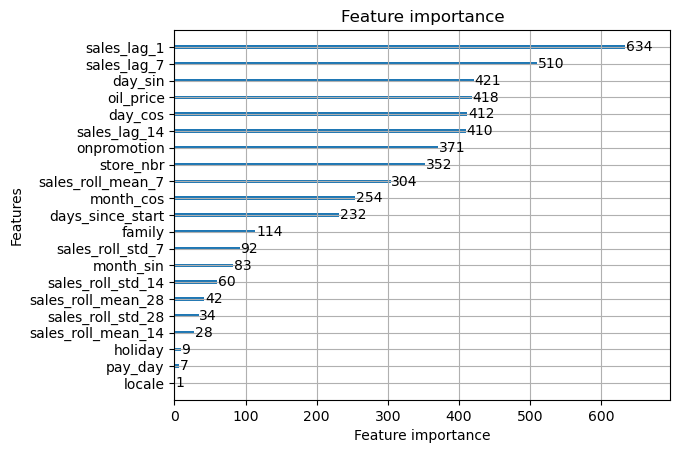

In [12]:
# print(model_lag.feature_importance())
# print(model_lag.feature_name())
lgb.plot_importance(model_lag,max_num_features=30)

In [ ]:
X_train

In [13]:
# Create a SHAP explainer for your trained LightGBM model
explainer = shap.TreeExplainer(model_lag)

# Calculate SHAP values on your validation set
shap_values = explainer.shap_values(X_val)

importance = np.abs(shap_values).mean(axis=0)

# Create a DataFrame for easy viewing
shap_importance = pd.DataFrame({
    "feature": X_val.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print(shap_importance)

               feature  importance
16   sales_roll_mean_7  264.166473
13         sales_lag_1  154.813222
14         sales_lag_7  126.468752
15        sales_lag_14   44.216784
6            oil_price   16.153130
2          onpromotion   11.362998
9              day_cos    8.189069
18  sales_roll_mean_28    7.603868
17  sales_roll_mean_14    6.115060
0            store_nbr    5.777380
8              day_sin    4.238824
1               family    3.195788
12    days_since_start    1.722727
11           month_cos    1.512231
19    sales_roll_std_7    1.296985
20   sales_roll_std_14    1.032034
21   sales_roll_std_28    0.660924
10           month_sin    0.536056
7              pay_day    0.017399
4              holiday    0.015392
5               locale    0.002108
3                 type    0.000000


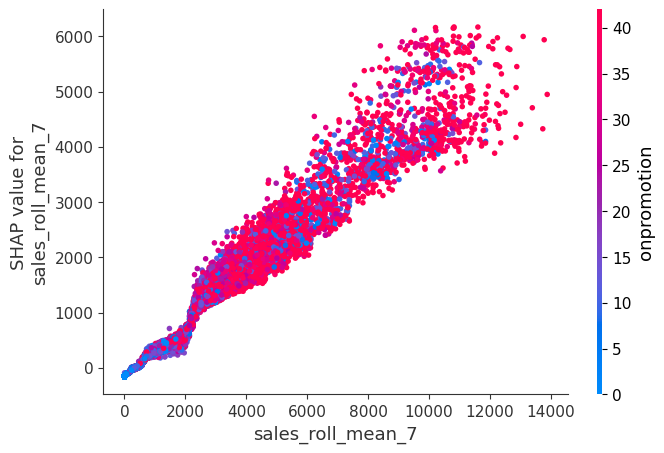

In [14]:
shap.dependence_plot("sales_roll_mean_7", shap_values, X_val, interaction_index="onpromotion")
# explainer.shap_values(X_train)

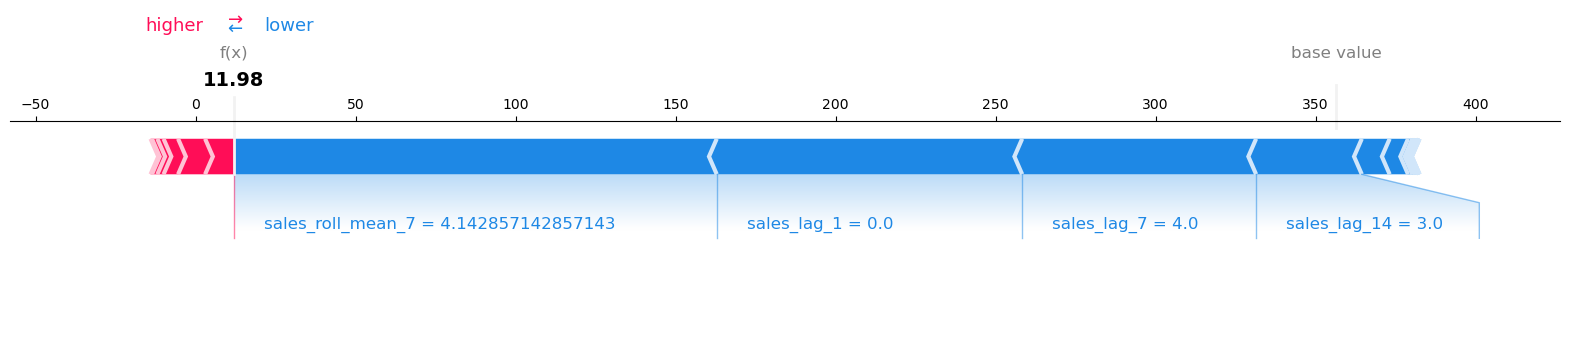

In [15]:
i=17
shap.force_plot(explainer.expected_value, shap_values[i], X_val.iloc[i],matplotlib=True)


In [16]:
explainer = shap.Explainer(model_lag)
shap_values = explainer(X_val)

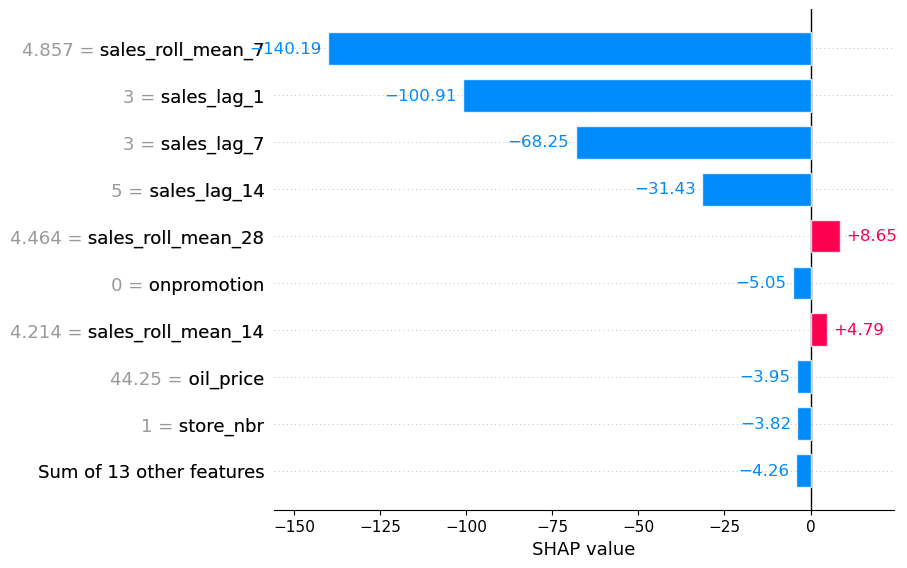

In [17]:
# visualize the first prediction's explanation
shap.plots.bar(shap_values[10])

Since we have categorical features which are not converted to numerical. Plotting them to understand feature interaction is a bit tricky. Lets put this on hold for the time being.
From this exercise we do understnd the engineered lag features play an important role in predicting the future sales.

Now lets get on with fine tuning the model.

### Fine tuning

In [18]:
total_cores = multiprocessing.cpu_count()
half_cores = max(1, total_cores //2) 

X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(
    X_train, y_train, test_size=0.4,random_state=40
)

# lgb_opt_train = lgb.Dataset(X_train_opt,label=y_train_opt, categorical_feature=categorical_feat)
# lgb_opt_val = lgb.Dataset(X_val_opt, label=y_val_opt,categorical_feature=categorical_feat)
trial_results = []

def objective(trial):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "device": "cpu",
        "num_threads": half_cores,
        "verbosity": -1,
        "seed": 20,
        # "feature_pre_filter":False,
        "num_leaves": trial.suggest_int("num_leaves",31,512),
        "max_depth": trial.suggest_int("max_depth",-1,16),
        "learning_rate": trial.suggest_float("learning_rate",0.005, 0.3, log=True),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 20, 200),
        "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 5.0),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.0, 5.0),
    }

    model =lgb.train(
        params,
        lgb_lag_train,
        valid_sets=[lgb_lag_val],
        num_boost_round= 5000,
        callbacks=[
            lgb.early_stopping(stopping_rounds=200)
        ]
    )

    rmse = model.best_score["valid_0"]["rmse"]
    trial_results.append({"trial":trial.number,"rmse":rmse,**params})
    
    return model.best_score["valid_0"]["rmse"]

# Running optuna
study_lag_1 = optuna.create_study(direction="minimize")
study_lag_1.optimize(objective, n_trials=50)

results_df = pd.DataFrame(trial_results)
print("Best params from Global search:", study_lag_1.best_trial.params)
print("Best RMSE value",study_lag_1.best_trial.value)

[I 2025-08-16 09:24:57,055] A new study created in memory with name: no-name-3e292aa4-0b17-4c0d-9e23-90ae5e2de321


Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:25:26,755] Trial 0 finished with value: 220.2658545343885 and parameters: {'num_leaves': 377, 'max_depth': 16, 'learning_rate': 0.022082904077452156, 'feature_fraction': 0.6399224117471596, 'bagging_fraction': 0.9656380417405823, 'bagging_freq': 4, 'min_data_in_leaf': 117, 'lambda_l1': 1.0467030474892054, 'lambda_l2': 2.8730540050727607}. Best is trial 0 with value: 220.2658545343885.


Early stopping, best iteration is:
[157]	valid_0's rmse: 220.266
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:25:37,539] Trial 1 finished with value: 224.71009559996526 and parameters: {'num_leaves': 265, 'max_depth': 10, 'learning_rate': 0.18908046288635016, 'feature_fraction': 0.8699143010969513, 'bagging_fraction': 0.627153889933952, 'bagging_freq': 8, 'min_data_in_leaf': 178, 'lambda_l1': 2.7606678297258753, 'lambda_l2': 2.770270275435936}. Best is trial 0 with value: 220.2658545343885.


Early stopping, best iteration is:
[18]	valid_0's rmse: 224.71
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:25:55,990] Trial 2 finished with value: 222.65960303961378 and parameters: {'num_leaves': 125, 'max_depth': 16, 'learning_rate': 0.013802823409523, 'feature_fraction': 0.9341003664760814, 'bagging_fraction': 0.6326998950755663, 'bagging_freq': 7, 'min_data_in_leaf': 118, 'lambda_l1': 4.459472118615925, 'lambda_l2': 2.568792171493997}. Best is trial 0 with value: 220.2658545343885.


Early stopping, best iteration is:
[268]	valid_0's rmse: 222.66
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:26:02,149] Trial 3 finished with value: 232.13126354103335 and parameters: {'num_leaves': 140, 'max_depth': 4, 'learning_rate': 0.1307650041753262, 'feature_fraction': 0.9754262089189956, 'bagging_fraction': 0.6710636865348231, 'bagging_freq': 5, 'min_data_in_leaf': 55, 'lambda_l1': 2.287222769855928, 'lambda_l2': 4.741833048583127}. Best is trial 0 with value: 220.2658545343885.


Early stopping, best iteration is:
[64]	valid_0's rmse: 232.131
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:26:12,280] Trial 4 finished with value: 226.13324030251215 and parameters: {'num_leaves': 51, 'max_depth': 16, 'learning_rate': 0.029970882029609847, 'feature_fraction': 0.8633418724227713, 'bagging_fraction': 0.7520652410853614, 'bagging_freq': 4, 'min_data_in_leaf': 120, 'lambda_l1': 1.3380823241793727, 'lambda_l2': 3.481886670505056}. Best is trial 0 with value: 220.2658545343885.


Early stopping, best iteration is:
[151]	valid_0's rmse: 226.133
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:26:30,960] Trial 5 finished with value: 225.00315853762976 and parameters: {'num_leaves': 270, 'max_depth': 6, 'learning_rate': 0.015498866334472228, 'feature_fraction': 0.7126116373821562, 'bagging_fraction': 0.77795695489629, 'bagging_freq': 7, 'min_data_in_leaf': 173, 'lambda_l1': 1.3360840797054996, 'lambda_l2': 3.0944773334104427}. Best is trial 0 with value: 220.2658545343885.


Early stopping, best iteration is:
[301]	valid_0's rmse: 225.003
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:26:58,871] Trial 6 finished with value: 228.128720991503 and parameters: {'num_leaves': 46, 'max_depth': 14, 'learning_rate': 0.005120939913896084, 'feature_fraction': 0.9827914326665889, 'bagging_fraction': 0.868145296373337, 'bagging_freq': 8, 'min_data_in_leaf': 28, 'lambda_l1': 3.905989953820639, 'lambda_l2': 0.07239027017276467}. Best is trial 0 with value: 220.2658545343885.


Early stopping, best iteration is:
[740]	valid_0's rmse: 228.129
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:27:14,197] Trial 7 finished with value: 223.66027995477276 and parameters: {'num_leaves': 92, 'max_depth': 13, 'learning_rate': 0.015767862152599958, 'feature_fraction': 0.8410909032642027, 'bagging_fraction': 0.6098409777630577, 'bagging_freq': 6, 'min_data_in_leaf': 112, 'lambda_l1': 4.666110810225622, 'lambda_l2': 4.45623520129857}. Best is trial 0 with value: 220.2658545343885.


Early stopping, best iteration is:
[249]	valid_0's rmse: 223.66
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:27:36,134] Trial 8 finished with value: 226.3017378998276 and parameters: {'num_leaves': 395, 'max_depth': -1, 'learning_rate': 0.2222991387372114, 'feature_fraction': 0.6265106466508876, 'bagging_fraction': 0.8979235827409131, 'bagging_freq': 7, 'min_data_in_leaf': 199, 'lambda_l1': 1.601795041727031, 'lambda_l2': 1.6122129457708128}. Best is trial 0 with value: 220.2658545343885.


Early stopping, best iteration is:
[14]	valid_0's rmse: 226.302
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:27:46,327] Trial 9 finished with value: 224.94084160912055 and parameters: {'num_leaves': 103, 'max_depth': -1, 'learning_rate': 0.060208742089634434, 'feature_fraction': 0.869207284352207, 'bagging_fraction': 0.8074012167977815, 'bagging_freq': 3, 'min_data_in_leaf': 155, 'lambda_l1': 2.376021357307632, 'lambda_l2': 0.19797369606695203}. Best is trial 0 with value: 220.2658545343885.


Early stopping, best iteration is:
[60]	valid_0's rmse: 224.941
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:27:58,479] Trial 10 finished with value: 218.7478141582036 and parameters: {'num_leaves': 508, 'max_depth': 10, 'learning_rate': 0.06885430022635838, 'feature_fraction': 0.611244784762113, 'bagging_fraction': 0.9987923360552589, 'bagging_freq': 1, 'min_data_in_leaf': 79, 'lambda_l1': 0.25244343258247504, 'lambda_l2': 1.503234122182486}. Best is trial 10 with value: 218.7478141582036.


Early stopping, best iteration is:
[52]	valid_0's rmse: 218.748
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:28:10,793] Trial 11 finished with value: 220.22920078215787 and parameters: {'num_leaves': 500, 'max_depth': 10, 'learning_rate': 0.06634681923581126, 'feature_fraction': 0.6024743707595528, 'bagging_fraction': 0.9994296526619325, 'bagging_freq': 1, 'min_data_in_leaf': 74, 'lambda_l1': 0.05276306040023826, 'lambda_l2': 1.2727762085123802}. Best is trial 10 with value: 218.7478141582036.


Early stopping, best iteration is:
[56]	valid_0's rmse: 220.229
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:28:21,477] Trial 12 finished with value: 220.62778899711049 and parameters: {'num_leaves': 504, 'max_depth': 10, 'learning_rate': 0.07534099659338896, 'feature_fraction': 0.7147815491540482, 'bagging_fraction': 0.9900759743690841, 'bagging_freq': 1, 'min_data_in_leaf': 74, 'lambda_l1': 0.026400562112100873, 'lambda_l2': 1.2996828099215594}. Best is trial 10 with value: 218.7478141582036.


Early stopping, best iteration is:
[49]	valid_0's rmse: 220.628
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:28:31,190] Trial 13 finished with value: 220.44650333763332 and parameters: {'num_leaves': 502, 'max_depth': 9, 'learning_rate': 0.06426369099294413, 'feature_fraction': 0.7000500345447489, 'bagging_fraction': 0.9240507903723122, 'bagging_freq': 1, 'min_data_in_leaf': 76, 'lambda_l1': 0.1468360250460546, 'lambda_l2': 1.3135069895701104}. Best is trial 10 with value: 218.7478141582036.


Early stopping, best iteration is:
[57]	valid_0's rmse: 220.447
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:28:41,528] Trial 14 finished with value: 226.0138561623874 and parameters: {'num_leaves': 418, 'max_depth': 7, 'learning_rate': 0.12733420006330667, 'feature_fraction': 0.6142931872169848, 'bagging_fraction': 0.9430955154692833, 'bagging_freq': 10, 'min_data_in_leaf': 82, 'lambda_l1': 0.5749844679362338, 'lambda_l2': 1.8244476475134597}. Best is trial 10 with value: 218.7478141582036.


Early stopping, best iteration is:
[28]	valid_0's rmse: 226.014
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:29:03,675] Trial 15 finished with value: 220.4379426151133 and parameters: {'num_leaves': 455, 'max_depth': 12, 'learning_rate': 0.044403702620039356, 'feature_fraction': 0.7705314302692574, 'bagging_fraction': 0.8470136109632904, 'bagging_freq': 2, 'min_data_in_leaf': 20, 'lambda_l1': 0.6940677596957869, 'lambda_l2': 0.8260737711646489}. Best is trial 10 with value: 218.7478141582036.


Early stopping, best iteration is:
[72]	valid_0's rmse: 220.438
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:29:14,185] Trial 16 finished with value: 231.06530828860446 and parameters: {'num_leaves': 332, 'max_depth': 4, 'learning_rate': 0.10174185124310947, 'feature_fraction': 0.6648472955914306, 'bagging_fraction': 0.9971473417686202, 'bagging_freq': 2, 'min_data_in_leaf': 47, 'lambda_l1': 3.066174538269309, 'lambda_l2': 1.8934126310192334}. Best is trial 10 with value: 218.7478141582036.


Early stopping, best iteration is:
[104]	valid_0's rmse: 231.065
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:29:32,494] Trial 17 finished with value: 219.88849223326378 and parameters: {'num_leaves': 201, 'max_depth': 11, 'learning_rate': 0.03553553260790647, 'feature_fraction': 0.7763287528397813, 'bagging_fraction': 0.7182918436679212, 'bagging_freq': 2, 'min_data_in_leaf': 85, 'lambda_l1': 1.8856338772727748, 'lambda_l2': 0.7289150582907248}. Best is trial 10 with value: 218.7478141582036.


Early stopping, best iteration is:
[105]	valid_0's rmse: 219.888
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:29:50,416] Trial 18 finished with value: 221.94164216743079 and parameters: {'num_leaves': 196, 'max_depth': 12, 'learning_rate': 0.03222618253762699, 'feature_fraction': 0.7752345315673831, 'bagging_fraction': 0.7167128608259866, 'bagging_freq': 3, 'min_data_in_leaf': 140, 'lambda_l1': 1.7946562200976124, 'lambda_l2': 0.6308020707937471}. Best is trial 10 with value: 218.7478141582036.


Early stopping, best iteration is:
[110]	valid_0's rmse: 221.942
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:30:35,020] Trial 19 finished with value: 220.4209368646882 and parameters: {'num_leaves': 207, 'max_depth': 8, 'learning_rate': 0.007212066813974492, 'feature_fraction': 0.8056407183577345, 'bagging_fraction': 0.694126815014618, 'bagging_freq': 2, 'min_data_in_leaf': 93, 'lambda_l1': 3.3618797475168525, 'lambda_l2': 0.719930202538443}. Best is trial 10 with value: 218.7478141582036.


Early stopping, best iteration is:
[561]	valid_0's rmse: 220.421
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:30:48,877] Trial 20 finished with value: 226.22991738572026 and parameters: {'num_leaves': 332, 'max_depth': 5, 'learning_rate': 0.04256293900143814, 'feature_fraction': 0.751513558437365, 'bagging_fraction': 0.8148454564749092, 'bagging_freq': 3, 'min_data_in_leaf': 53, 'lambda_l1': 1.9786231141378217, 'lambda_l2': 2.1907991147360493}. Best is trial 10 with value: 218.7478141582036.


Early stopping, best iteration is:
[206]	valid_0's rmse: 226.23
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:31:00,606] Trial 21 finished with value: 218.75227731929917 and parameters: {'num_leaves': 454, 'max_depth': 11, 'learning_rate': 0.09213375455694245, 'feature_fraction': 0.6030476808251627, 'bagging_fraction': 0.9161890505920967, 'bagging_freq': 1, 'min_data_in_leaf': 91, 'lambda_l1': 0.7493392719302534, 'lambda_l2': 1.1319372407964845}. Best is trial 10 with value: 218.7478141582036.


Early stopping, best iteration is:
[39]	valid_0's rmse: 218.752
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:31:09,505] Trial 22 finished with value: 222.73867379971372 and parameters: {'num_leaves': 215, 'max_depth': 11, 'learning_rate': 0.10113695881014938, 'feature_fraction': 0.6684604930939113, 'bagging_fraction': 0.9146093285873318, 'bagging_freq': 1, 'min_data_in_leaf': 91, 'lambda_l1': 0.6851865453115635, 'lambda_l2': 0.9688609396074697}. Best is trial 10 with value: 218.7478141582036.


Early stopping, best iteration is:
[36]	valid_0's rmse: 222.739
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:31:27,412] Trial 23 finished with value: 220.40297659491006 and parameters: {'num_leaves': 453, 'max_depth': 14, 'learning_rate': 0.1672653288936571, 'feature_fraction': 0.667655981669066, 'bagging_fraction': 0.7486411192693242, 'bagging_freq': 2, 'min_data_in_leaf': 101, 'lambda_l1': 1.0313042140049142, 'lambda_l2': 0.38420257902662514}. Best is trial 10 with value: 218.7478141582036.


Early stopping, best iteration is:
[21]	valid_0's rmse: 220.403
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:31:48,590] Trial 24 finished with value: 221.82379635347834 and parameters: {'num_leaves': 329, 'max_depth': 8, 'learning_rate': 0.023756490279619267, 'feature_fraction': 0.9216449404062241, 'bagging_fraction': 0.8768189679429788, 'bagging_freq': 4, 'min_data_in_leaf': 131, 'lambda_l1': 0.4052490079824209, 'lambda_l2': 2.13961937996055}. Best is trial 10 with value: 218.7478141582036.


Early stopping, best iteration is:
[179]	valid_0's rmse: 221.824
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:32:02,254] Trial 25 finished with value: 217.50774987075224 and parameters: {'num_leaves': 446, 'max_depth': 12, 'learning_rate': 0.050286576375791855, 'feature_fraction': 0.7449414061735045, 'bagging_fraction': 0.9536842889921734, 'bagging_freq': 1, 'min_data_in_leaf': 42, 'lambda_l1': 1.0636397827699762, 'lambda_l2': 1.1098829796340537}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[70]	valid_0's rmse: 217.508
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:32:13,383] Trial 26 finished with value: 231.7368949094074 and parameters: {'num_leaves': 451, 'max_depth': 14, 'learning_rate': 0.275881921697098, 'feature_fraction': 0.6446435382050189, 'bagging_fraction': 0.9535368248023554, 'bagging_freq': 1, 'min_data_in_leaf': 36, 'lambda_l1': 1.0441991272344633, 'lambda_l2': 1.537365681471236}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[9]	valid_0's rmse: 231.737
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:32:30,163] Trial 27 finished with value: 239.66463017006816 and parameters: {'num_leaves': 372, 'max_depth': 2, 'learning_rate': 0.09124668392575036, 'feature_fraction': 0.734291357454092, 'bagging_fraction': 0.9720464595926332, 'bagging_freq': 3, 'min_data_in_leaf': 64, 'lambda_l1': 0.5044331799319811, 'lambda_l2': 1.063838304341691}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[560]	valid_0's rmse: 239.665
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:32:44,116] Trial 28 finished with value: 219.7513202952941 and parameters: {'num_leaves': 426, 'max_depth': 12, 'learning_rate': 0.049938562925858083, 'feature_fraction': 0.6906439412322212, 'bagging_fraction': 0.9326535155923575, 'bagging_freq': 1, 'min_data_in_leaf': 42, 'lambda_l1': 0.902021089489966, 'lambda_l2': 2.2242747325096603}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[73]	valid_0's rmse: 219.751
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:32:59,979] Trial 29 finished with value: 221.36005024814392 and parameters: {'num_leaves': 472, 'max_depth': 9, 'learning_rate': 0.08280261411622644, 'feature_fraction': 0.6398144179388554, 'bagging_fraction': 0.9660707172811495, 'bagging_freq': 5, 'min_data_in_leaf': 67, 'lambda_l1': 1.3950652173842086, 'lambda_l2': 0.42998233452498824}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[48]	valid_0's rmse: 221.36
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:33:18,441] Trial 30 finished with value: 223.2914336596079 and parameters: {'num_leaves': 384, 'max_depth': 15, 'learning_rate': 0.1317406782546739, 'feature_fraction': 0.8138036105585691, 'bagging_fraction': 0.8805310615466585, 'bagging_freq': 10, 'min_data_in_leaf': 103, 'lambda_l1': 0.4082657002729533, 'lambda_l2': 3.273947931701315}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[26]	valid_0's rmse: 223.291
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:33:32,582] Trial 31 finished with value: 219.6978182141819 and parameters: {'num_leaves': 420, 'max_depth': 13, 'learning_rate': 0.05153077059482122, 'feature_fraction': 0.6897065012307692, 'bagging_fraction': 0.9382118329581632, 'bagging_freq': 1, 'min_data_in_leaf': 35, 'lambda_l1': 0.9224524153789556, 'lambda_l2': 2.4172112775373016}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[70]	valid_0's rmse: 219.698
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:33:55,046] Trial 32 finished with value: 221.42080655104712 and parameters: {'num_leaves': 416, 'max_depth': 13, 'learning_rate': 0.05342160105261261, 'feature_fraction': 0.6034580568763506, 'bagging_fraction': 0.9068616062159591, 'bagging_freq': 2, 'min_data_in_leaf': 34, 'lambda_l1': 0.9198059089836814, 'lambda_l2': 2.738894234309035}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[68]	valid_0's rmse: 221.421
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:34:14,902] Trial 33 finished with value: 219.46782901697642 and parameters: {'num_leaves': 478, 'max_depth': 11, 'learning_rate': 0.02519515814652942, 'feature_fraction': 0.6451030075752592, 'bagging_fraction': 0.8376388121865685, 'bagging_freq': 1, 'min_data_in_leaf': 55, 'lambda_l1': 1.3196156095924205, 'lambda_l2': 3.7528571770884156}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[137]	valid_0's rmse: 219.468
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:34:44,276] Trial 34 finished with value: 220.07467982552706 and parameters: {'num_leaves': 479, 'max_depth': 11, 'learning_rate': 0.022850051507895784, 'feature_fraction': 0.6441075758165055, 'bagging_fraction': 0.8397071337417599, 'bagging_freq': 4, 'min_data_in_leaf': 55, 'lambda_l1': 1.560103670487535, 'lambda_l2': 3.9850423442231366}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[155]	valid_0's rmse: 220.075
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:35:30,354] Trial 35 finished with value: 221.15886103479136 and parameters: {'num_leaves': 365, 'max_depth': 9, 'learning_rate': 0.010233969981361708, 'feature_fraction': 0.629297825250089, 'bagging_fraction': 0.9791051069161889, 'bagging_freq': 2, 'min_data_in_leaf': 62, 'lambda_l1': 2.625412837064212, 'lambda_l2': 3.8684840034907064}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[364]	valid_0's rmse: 221.159
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:35:55,136] Trial 36 finished with value: 219.41042944667677 and parameters: {'num_leaves': 480, 'max_depth': 10, 'learning_rate': 0.02782202468588742, 'feature_fraction': 0.6711604023813564, 'bagging_fraction': 0.8399557009946581, 'bagging_freq': 3, 'min_data_in_leaf': 98, 'lambda_l1': 1.2822658022834386, 'lambda_l2': 4.799768385645471}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[128]	valid_0's rmse: 219.41
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:36:27,813] Trial 37 finished with value: 219.87241455639398 and parameters: {'num_leaves': 509, 'max_depth': 10, 'learning_rate': 0.018491590364949604, 'feature_fraction': 0.7259300253385232, 'bagging_fraction': 0.9030767749603936, 'bagging_freq': 3, 'min_data_in_leaf': 124, 'lambda_l1': 2.0983323439470234, 'lambda_l2': 4.841503761023067}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[206]	valid_0's rmse: 219.872
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:36:43,125] Trial 38 finished with value: 223.51811160519728 and parameters: {'num_leaves': 294, 'max_depth': 7, 'learning_rate': 0.038988718812492766, 'feature_fraction': 0.6706474401438978, 'bagging_fraction': 0.953737346170539, 'bagging_freq': 4, 'min_data_in_leaf': 111, 'lambda_l1': 0.31337859479561375, 'lambda_l2': 1.6796238592526311}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[115]	valid_0's rmse: 223.518
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:37:22,142] Trial 39 finished with value: 219.30999069195212 and parameters: {'num_leaves': 446, 'max_depth': 16, 'learning_rate': 0.012076681220540748, 'feature_fraction': 0.7440478597586871, 'bagging_fraction': 0.7844446625855825, 'bagging_freq': 5, 'min_data_in_leaf': 100, 'lambda_l1': 1.316841483054943, 'lambda_l2': 4.3894259976762555}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[304]	valid_0's rmse: 219.31
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:38:15,305] Trial 40 finished with value: 219.55785557899662 and parameters: {'num_leaves': 438, 'max_depth': 16, 'learning_rate': 0.008043215160858075, 'feature_fraction': 0.8285004931890647, 'bagging_fraction': 0.7846457972862669, 'bagging_freq': 9, 'min_data_in_leaf': 147, 'lambda_l1': 1.6945385110381737, 'lambda_l2': 4.4120168009203145}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[483]	valid_0's rmse: 219.558
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:38:54,447] Trial 41 finished with value: 219.07911372317417 and parameters: {'num_leaves': 478, 'max_depth': 15, 'learning_rate': 0.013385977020975067, 'feature_fraction': 0.7488112652085778, 'bagging_fraction': 0.7697465704273146, 'bagging_freq': 6, 'min_data_in_leaf': 98, 'lambda_l1': 1.2462705535279284, 'lambda_l2': 4.978929027517747}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[276]	valid_0's rmse: 219.079
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:39:31,873] Trial 42 finished with value: 220.34702219553427 and parameters: {'num_leaves': 395, 'max_depth': 15, 'learning_rate': 0.011573587878548137, 'feature_fraction': 0.8994947915257303, 'bagging_fraction': 0.7699529795741215, 'bagging_freq': 6, 'min_data_in_leaf': 106, 'lambda_l1': 0.7080368554075931, 'lambda_l2': 4.487236647476373}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[300]	valid_0's rmse: 220.347
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:40:04,457] Trial 43 finished with value: 219.2626750698137 and parameters: {'num_leaves': 463, 'max_depth': 16, 'learning_rate': 0.017731314959442652, 'feature_fraction': 0.7370021931229273, 'bagging_fraction': 0.7454090635694945, 'bagging_freq': 6, 'min_data_in_leaf': 88, 'lambda_l1': 1.1908526478923147, 'lambda_l2': 4.295372633248058}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[206]	valid_0's rmse: 219.263
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:40:37,671] Trial 44 finished with value: 220.1188123352672 and parameters: {'num_leaves': 471, 'max_depth': 15, 'learning_rate': 0.018228680366450586, 'feature_fraction': 0.7594012806758259, 'bagging_fraction': 0.6488114317678709, 'bagging_freq': 6, 'min_data_in_leaf': 90, 'lambda_l1': 0.2513363926886568, 'lambda_l2': 4.139295267633167}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[201]	valid_0's rmse: 220.119
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:40:57,619] Trial 45 finished with value: 220.95154430394703 and parameters: {'num_leaves': 511, 'max_depth': 14, 'learning_rate': 0.07456781914593445, 'feature_fraction': 0.8508541414811241, 'bagging_fraction': 0.7249805779672349, 'bagging_freq': 8, 'min_data_in_leaf': 81, 'lambda_l1': 2.199818174694307, 'lambda_l2': 2.979488884704269}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[47]	valid_0's rmse: 220.952
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:41:49,602] Trial 46 finished with value: 219.61341971172493 and parameters: {'num_leaves': 351, 'max_depth': 15, 'learning_rate': 0.0060430203332332375, 'feature_fraction': 0.7224579250080395, 'bagging_fraction': 0.748865495886582, 'bagging_freq': 7, 'min_data_in_leaf': 118, 'lambda_l1': 0.7587725434467077, 'lambda_l2': 1.0584825733641616}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[588]	valid_0's rmse: 219.613
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:42:21,374] Trial 47 finished with value: 219.14198108576238 and parameters: {'num_leaves': 406, 'max_depth': 13, 'learning_rate': 0.015079134662070524, 'feature_fraction': 0.7852758160456698, 'bagging_fraction': 0.8135818930700223, 'bagging_freq': 7, 'min_data_in_leaf': 71, 'lambda_l1': 1.1830130416010898, 'lambda_l2': 1.4105989556132057}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[237]	valid_0's rmse: 219.142
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:42:37,853] Trial 48 finished with value: 222.88038350973466 and parameters: {'num_leaves': 403, 'max_depth': 13, 'learning_rate': 0.129371845382838, 'feature_fraction': 0.7851920525250793, 'bagging_fraction': 0.8199250084025256, 'bagging_freq': 7, 'min_data_in_leaf': 75, 'lambda_l1': 1.499785609220868, 'lambda_l2': 1.4742404105894293}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[25]	valid_0's rmse: 222.88
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:43:30,402] Trial 49 finished with value: 218.85624786016035 and parameters: {'num_leaves': 486, 'max_depth': 12, 'learning_rate': 0.008605583194861077, 'feature_fraction': 0.8864847724514986, 'bagging_fraction': 0.8601746174461103, 'bagging_freq': 9, 'min_data_in_leaf': 70, 'lambda_l1': 3.9810242319340454, 'lambda_l2': 1.7933399896962747}. Best is trial 25 with value: 217.50774987075224.


Early stopping, best iteration is:
[442]	valid_0's rmse: 218.856
Best params from Global search: {'num_leaves': 446, 'max_depth': 12, 'learning_rate': 0.050286576375791855, 'feature_fraction': 0.7449414061735045, 'bagging_fraction': 0.9536842889921734, 'bagging_freq': 1, 'min_data_in_leaf': 42, 'lambda_l1': 1.0636397827699762, 'lambda_l2': 1.1098829796340537}
Best RMSE value 217.50774987075224


In [178]:
### Retraining on full dataset

params1 = study_lag_1.best_trial.params
params1.update({
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "device_type": "cpu",
    "seed": 20,
})

model_lag1 = lgb.train(
    params1,
    lgb_lag_train,
    valid_sets = [lgb_lag_train, lgb_lag_val],
    valid_names=["train","val"],
    num_boost_round = 5000,
    callbacks=[
        # lgb.early_stopping(stopping_rounds=200),
        lgb.log_evaluation(period=200)  # print every 50 rounds
    ]
)

[200]	train's rmse: 203.502	val's rmse: 227.973
[400]	train's rmse: 185.877	val's rmse: 232.61
[600]	train's rmse: 174.329	val's rmse: 235.452
[800]	train's rmse: 164.754	val's rmse: 239.72
[1000]	train's rmse: 157.083	val's rmse: 240.382
[1200]	train's rmse: 150.277	val's rmse: 242.374
[1400]	train's rmse: 143.835	val's rmse: 244.562
[1600]	train's rmse: 138.121	val's rmse: 245.845
[1800]	train's rmse: 132.75	val's rmse: 246.536
[2000]	train's rmse: 127.925	val's rmse: 247.702
[2200]	train's rmse: 123.312	val's rmse: 248.37
[2400]	train's rmse: 119.199	val's rmse: 249.688
[2600]	train's rmse: 115.247	val's rmse: 250.819
[2800]	train's rmse: 111.325	val's rmse: 251.275
[3000]	train's rmse: 107.615	val's rmse: 251.863
[3200]	train's rmse: 104.03	val's rmse: 252.594
[3400]	train's rmse: 100.626	val's rmse: 252.973
[3600]	train's rmse: 97.6613	val's rmse: 253.999
[3800]	train's rmse: 94.633	val's rmse: 254.781
[4000]	train's rmse: 91.96	val's rmse: 255.135
[4200]	train's rmse: 89.247	val'

What we see in the above cell is a classic example of over fitting. After the initial iteration though fit to training is improving, the valid set RMSE is getting worser. THis is beasically because of the param values 'num_leaves': 414, 'max_depth': 14, coming from fine tuning. Since we allow a larger range for num of leave nodes and depth, it is not a simple model. Keep in mind "The simplest model is always the most probable model" (Occum's razor).

Inorder to avoid this, we limit the range of hyper-parameters avoiding params supporting complex models.

In [19]:
# Cpu cores

total_cores = multiprocessing.cpu_count()
half_cores = max(1, total_cores //2) 

X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(
    X_train, y_train, test_size=0.4,random_state=40
)

lgb_opt_train = lgb.Dataset(X_train_opt,label=y_train_opt, categorical_feature=categorical_feat)
lgb_opt_val = lgb.Dataset(X_val_opt, label=y_val_opt,categorical_feature=categorical_feat)

trial_results = []

def objective(trial):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "device": "cpu",
        "num_threads": half_cores,
        "verbosity": -1,
        "seed": 20,
        # "feature_pre_filter":False,
        "num_leaves": trial.suggest_int("num_leaves",31,255),
        "max_depth": trial.suggest_int("max_depth",4,16),
        "learning_rate": trial.suggest_float("learning_rate",0.005, 0.1, log=True),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 50, 200),
        "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 5.0),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.0, 5.0),
    }

    model =lgb.train(
        params,
        lgb_lag_train,
        valid_sets=[lgb_lag_val],
        num_boost_round= 5000,
        callbacks=[
            lgb.early_stopping(stopping_rounds=200)
        ]
    )

    rmse = model.best_score["valid_0"]["rmse"]
    trial_results.append({"trial":trial.number,"rmse":rmse,**params})
    
    return model.best_score["valid_0"]["rmse"]

# Running optuna
study_lag = optuna.create_study(direction="minimize")
study_lag.optimize(objective, n_trials=50)

results_df = pd.DataFrame(trial_results)
print("Best params from Global search:", study_lag.best_trial.params)
print("Best RMSE value",study_lag.best_trial.value)

[I 2025-08-16 09:53:20,435] A new study created in memory with name: no-name-47dedc88-e1c0-4451-88bf-04506f9f196a


Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:53:35,466] Trial 0 finished with value: 220.8867011882775 and parameters: {'num_leaves': 213, 'max_depth': 16, 'learning_rate': 0.07120275071307065, 'feature_fraction': 0.946376515754892, 'bagging_fraction': 0.9720844783589638, 'bagging_freq': 6, 'min_data_in_leaf': 131, 'lambda_l1': 3.8298026914819463, 'lambda_l2': 3.567730877757907}. Best is trial 0 with value: 220.8867011882775.


Early stopping, best iteration is:
[49]	valid_0's rmse: 220.887
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:53:42,619] Trial 1 finished with value: 228.69888760008263 and parameters: {'num_leaves': 37, 'max_depth': 16, 'learning_rate': 0.09196575131127403, 'feature_fraction': 0.6903192926564048, 'bagging_fraction': 0.9996734813688437, 'bagging_freq': 5, 'min_data_in_leaf': 134, 'lambda_l1': 4.152137335163547, 'lambda_l2': 4.673034028171888}. Best is trial 0 with value: 220.8867011882775.


Early stopping, best iteration is:
[52]	valid_0's rmse: 228.699
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:53:53,309] Trial 2 finished with value: 224.2463827569292 and parameters: {'num_leaves': 224, 'max_depth': 6, 'learning_rate': 0.06643792282854687, 'feature_fraction': 0.6430466580113551, 'bagging_fraction': 0.8041270095972045, 'bagging_freq': 8, 'min_data_in_leaf': 112, 'lambda_l1': 2.4318445901259893, 'lambda_l2': 4.130712590367821}. Best is trial 0 with value: 220.8867011882775.


Early stopping, best iteration is:
[79]	valid_0's rmse: 224.246
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:54:19,939] Trial 3 finished with value: 221.81917901897845 and parameters: {'num_leaves': 245, 'max_depth': 9, 'learning_rate': 0.01999866595821321, 'feature_fraction': 0.6290354809231163, 'bagging_fraction': 0.9629257714201898, 'bagging_freq': 7, 'min_data_in_leaf': 164, 'lambda_l1': 0.2381325858000949, 'lambda_l2': 0.9821401758855197}. Best is trial 0 with value: 220.8867011882775.


Early stopping, best iteration is:
[205]	valid_0's rmse: 221.819
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:54:28,413] Trial 4 finished with value: 224.4938409012723 and parameters: {'num_leaves': 191, 'max_depth': 6, 'learning_rate': 0.049377322295114205, 'feature_fraction': 0.615137159064827, 'bagging_fraction': 0.75516727965953, 'bagging_freq': 1, 'min_data_in_leaf': 140, 'lambda_l1': 1.4355670636457725, 'lambda_l2': 3.5640984191845626}. Best is trial 0 with value: 220.8867011882775.


Early stopping, best iteration is:
[116]	valid_0's rmse: 224.494
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:54:46,036] Trial 5 finished with value: 229.56959651031792 and parameters: {'num_leaves': 88, 'max_depth': 4, 'learning_rate': 0.0154316384114133, 'feature_fraction': 0.7269593966355324, 'bagging_fraction': 0.7938764541450902, 'bagging_freq': 1, 'min_data_in_leaf': 129, 'lambda_l1': 4.226476341217219, 'lambda_l2': 1.2311566062608077}. Best is trial 0 with value: 220.8867011882775.


Early stopping, best iteration is:
[777]	valid_0's rmse: 229.57
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:54:59,257] Trial 6 finished with value: 222.34219681020676 and parameters: {'num_leaves': 149, 'max_depth': 15, 'learning_rate': 0.07793112717305856, 'feature_fraction': 0.9758769452147747, 'bagging_fraction': 0.7826932064821213, 'bagging_freq': 10, 'min_data_in_leaf': 164, 'lambda_l1': 4.592665374767252, 'lambda_l2': 0.8408414342626436}. Best is trial 0 with value: 220.8867011882775.


Early stopping, best iteration is:
[46]	valid_0's rmse: 222.342
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:55:27,586] Trial 7 finished with value: 225.9193972551864 and parameters: {'num_leaves': 92, 'max_depth': 5, 'learning_rate': 0.01297331149411473, 'feature_fraction': 0.7866966562147887, 'bagging_fraction': 0.7485837417149682, 'bagging_freq': 2, 'min_data_in_leaf': 121, 'lambda_l1': 2.08453597335313, 'lambda_l2': 2.603265054711266}. Best is trial 0 with value: 220.8867011882775.


Early stopping, best iteration is:
[613]	valid_0's rmse: 225.919
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:55:43,792] Trial 8 finished with value: 224.57339054179735 and parameters: {'num_leaves': 102, 'max_depth': 6, 'learning_rate': 0.021322873011828933, 'feature_fraction': 0.6715922084968003, 'bagging_fraction': 0.8539377579863432, 'bagging_freq': 5, 'min_data_in_leaf': 103, 'lambda_l1': 1.6778592543520676, 'lambda_l2': 0.9328484719930996}. Best is trial 0 with value: 220.8867011882775.


Early stopping, best iteration is:
[207]	valid_0's rmse: 224.573
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:55:56,590] Trial 9 finished with value: 225.09102449396835 and parameters: {'num_leaves': 76, 'max_depth': 5, 'learning_rate': 0.03723749620871455, 'feature_fraction': 0.7053744690498179, 'bagging_fraction': 0.9158764379780668, 'bagging_freq': 8, 'min_data_in_leaf': 58, 'lambda_l1': 2.7477678425913754, 'lambda_l2': 0.4052905391404549}. Best is trial 0 with value: 220.8867011882775.


Early stopping, best iteration is:
[190]	valid_0's rmse: 225.091
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:56:44,075] Trial 10 finished with value: 221.35607801648663 and parameters: {'num_leaves': 177, 'max_depth': 13, 'learning_rate': 0.005100202716915093, 'feature_fraction': 0.9663915310389436, 'bagging_fraction': 0.6181855419605171, 'bagging_freq': 3, 'min_data_in_leaf': 197, 'lambda_l1': 3.3988365251206423, 'lambda_l2': 2.729810334858001}. Best is trial 0 with value: 220.8867011882775.


Early stopping, best iteration is:
[759]	valid_0's rmse: 221.356
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:57:28,786] Trial 11 finished with value: 221.84632668545612 and parameters: {'num_leaves': 183, 'max_depth': 13, 'learning_rate': 0.005246755827869542, 'feature_fraction': 0.9806553576878595, 'bagging_fraction': 0.6032378204908413, 'bagging_freq': 3, 'min_data_in_leaf': 190, 'lambda_l1': 3.3747340279316336, 'lambda_l2': 2.7196110495380763}. Best is trial 0 with value: 220.8867011882775.


Early stopping, best iteration is:
[708]	valid_0's rmse: 221.846
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:58:12,696] Trial 12 finished with value: 221.59452126915306 and parameters: {'num_leaves': 192, 'max_depth': 13, 'learning_rate': 0.005784439185060932, 'feature_fraction': 0.8992117949266133, 'bagging_fraction': 0.626934351581717, 'bagging_freq': 4, 'min_data_in_leaf': 199, 'lambda_l1': 3.369002872931257, 'lambda_l2': 3.2920527697959674}. Best is trial 0 with value: 220.8867011882775.


Early stopping, best iteration is:
[672]	valid_0's rmse: 221.595
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:58:41,016] Trial 13 finished with value: 221.49969449958627 and parameters: {'num_leaves': 155, 'max_depth': 13, 'learning_rate': 0.008093494007884273, 'feature_fraction': 0.8934214645562185, 'bagging_fraction': 0.677455535253651, 'bagging_freq': 6, 'min_data_in_leaf': 75, 'lambda_l1': 3.505276733741234, 'lambda_l2': 1.8036904040518764}. Best is trial 0 with value: 220.8867011882775.


Early stopping, best iteration is:
[468]	valid_0's rmse: 221.5
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:59:00,841] Trial 14 finished with value: 221.5402858492382 and parameters: {'num_leaves': 217, 'max_depth': 11, 'learning_rate': 0.03467644173661038, 'feature_fraction': 0.9047623918648389, 'bagging_fraction': 0.878477445687437, 'bagging_freq': 3, 'min_data_in_leaf': 170, 'lambda_l1': 4.835406244573461, 'lambda_l2': 3.559189726259431}. Best is trial 0 with value: 220.8867011882775.


Early stopping, best iteration is:
[108]	valid_0's rmse: 221.54
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 09:59:33,751] Trial 15 finished with value: 221.00747044817038 and parameters: {'num_leaves': 247, 'max_depth': 15, 'learning_rate': 0.010017511235018931, 'feature_fraction': 0.8403848089518716, 'bagging_fraction': 0.6955341506442522, 'bagging_freq': 4, 'min_data_in_leaf': 178, 'lambda_l1': 3.6790605028668155, 'lambda_l2': 2.025150570633038}. Best is trial 0 with value: 220.8867011882775.


Early stopping, best iteration is:
[372]	valid_0's rmse: 221.007
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:00:03,569] Trial 16 finished with value: 219.89784331479703 and parameters: {'num_leaves': 250, 'max_depth': 16, 'learning_rate': 0.010137223477268033, 'feature_fraction': 0.8482889791423563, 'bagging_fraction': 0.7030788816206459, 'bagging_freq': 6, 'min_data_in_leaf': 93, 'lambda_l1': 4.017725765201422, 'lambda_l2': 1.8473971002298617}. Best is trial 16 with value: 219.89784331479703.


Early stopping, best iteration is:
[363]	valid_0's rmse: 219.898
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:00:20,467] Trial 17 finished with value: 221.79065192445157 and parameters: {'num_leaves': 216, 'max_depth': 16, 'learning_rate': 0.028271330830080394, 'feature_fraction': 0.8329842415932466, 'bagging_fraction': 0.7109370360310712, 'bagging_freq': 7, 'min_data_in_leaf': 86, 'lambda_l1': 4.988509988853572, 'lambda_l2': 2.03592165443545}. Best is trial 16 with value: 219.89784331479703.


Early stopping, best iteration is:
[127]	valid_0's rmse: 221.791
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:00:35,077] Trial 18 finished with value: 221.4415328168094 and parameters: {'num_leaves': 255, 'max_depth': 9, 'learning_rate': 0.053469561724889265, 'feature_fraction': 0.7597617208881351, 'bagging_fraction': 0.8420932443009935, 'bagging_freq': 10, 'min_data_in_leaf': 91, 'lambda_l1': 4.059995407011096, 'lambda_l2': 4.979800824730177}. Best is trial 16 with value: 219.89784331479703.


Early stopping, best iteration is:
[68]	valid_0's rmse: 221.442
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:01:12,005] Trial 19 finished with value: 220.30475396076048 and parameters: {'num_leaves': 224, 'max_depth': 14, 'learning_rate': 0.008571963079950107, 'feature_fraction': 0.9389442064001791, 'bagging_fraction': 0.9338484475020555, 'bagging_freq': 6, 'min_data_in_leaf': 147, 'lambda_l1': 2.8491116503600957, 'lambda_l2': 4.088800848670532}. Best is trial 16 with value: 219.89784331479703.


Early stopping, best iteration is:
[443]	valid_0's rmse: 220.305
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:01:42,776] Trial 20 finished with value: 223.00686241750276 and parameters: {'num_leaves': 127, 'max_depth': 11, 'learning_rate': 0.008352007731820554, 'feature_fraction': 0.8484168070709114, 'bagging_fraction': 0.9261847081018526, 'bagging_freq': 8, 'min_data_in_leaf': 155, 'lambda_l1': 2.845181773276428, 'lambda_l2': 4.229380982388826}. Best is trial 16 with value: 219.89784331479703.


Early stopping, best iteration is:
[476]	valid_0's rmse: 223.007
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:02:10,044] Trial 21 finished with value: 219.73508598033592 and parameters: {'num_leaves': 231, 'max_depth': 15, 'learning_rate': 0.01434768682163922, 'feature_fraction': 0.9348179303108038, 'bagging_fraction': 0.9715029601344938, 'bagging_freq': 6, 'min_data_in_leaf': 148, 'lambda_l1': 2.8679050549607177, 'lambda_l2': 3.172086216849297}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[255]	valid_0's rmse: 219.735
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:02:38,721] Trial 22 finished with value: 220.89835443860966 and parameters: {'num_leaves': 232, 'max_depth': 14, 'learning_rate': 0.012256834775475062, 'feature_fraction': 0.9426959725479561, 'bagging_fraction': 0.9278385167043992, 'bagging_freq': 7, 'min_data_in_leaf': 147, 'lambda_l1': 2.899931945210097, 'lambda_l2': 3.1598420614538147}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[292]	valid_0's rmse: 220.898
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:03:03,331] Trial 23 finished with value: 219.98158380271957 and parameters: {'num_leaves': 237, 'max_depth': 14, 'learning_rate': 0.015799014618922334, 'feature_fraction': 0.8748798910398904, 'bagging_fraction': 0.8878471757119688, 'bagging_freq': 6, 'min_data_in_leaf': 112, 'lambda_l1': 0.8456363115446615, 'lambda_l2': 3.99667875193503}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[231]	valid_0's rmse: 219.982
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:03:26,297] Trial 24 finished with value: 221.01265789114157 and parameters: {'num_leaves': 202, 'max_depth': 15, 'learning_rate': 0.01608940843552742, 'feature_fraction': 0.8743973572903397, 'bagging_fraction': 0.8667075273893495, 'bagging_freq': 5, 'min_data_in_leaf': 107, 'lambda_l1': 0.7026053595902504, 'lambda_l2': 1.782146336402221}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[246]	valid_0's rmse: 221.013
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:03:50,742] Trial 25 finished with value: 221.84320304471575 and parameters: {'num_leaves': 241, 'max_depth': 11, 'learning_rate': 0.01718729807308348, 'feature_fraction': 0.8066741414909062, 'bagging_fraction': 0.8965182936388104, 'bagging_freq': 9, 'min_data_in_leaf': 74, 'lambda_l1': 1.1088617791874307, 'lambda_l2': 3.025697966637853}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[206]	valid_0's rmse: 221.843
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:04:20,767] Trial 26 finished with value: 220.36968213708118 and parameters: {'num_leaves': 253, 'max_depth': 14, 'learning_rate': 0.011448782467416239, 'feature_fraction': 0.8616465305571552, 'bagging_fraction': 0.8268269491051699, 'bagging_freq': 4, 'min_data_in_leaf': 119, 'lambda_l1': 0.07347824521285506, 'lambda_l2': 2.3066166324149684}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[312]	valid_0's rmse: 220.37
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:04:39,857] Trial 27 finished with value: 221.81867780308198 and parameters: {'num_leaves': 204, 'max_depth': 12, 'learning_rate': 0.02559445390671825, 'feature_fraction': 0.8090582790687766, 'bagging_fraction': 0.9646264295533701, 'bagging_freq': 7, 'min_data_in_leaf': 96, 'lambda_l1': 2.113291460622046, 'lambda_l2': 1.496085411897929}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[140]	valid_0's rmse: 221.819
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:05:15,912] Trial 28 finished with value: 222.17805619275205 and parameters: {'num_leaves': 172, 'max_depth': 15, 'learning_rate': 0.007143656240662369, 'feature_fraction': 0.7703108702432628, 'bagging_fraction': 0.9913786640356665, 'bagging_freq': 6, 'min_data_in_leaf': 79, 'lambda_l1': 0.8469346335435979, 'lambda_l2': 4.513615354567809}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[511]	valid_0's rmse: 222.178
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:05:38,695] Trial 29 finished with value: 221.36313809719243 and parameters: {'num_leaves': 234, 'max_depth': 12, 'learning_rate': 0.014082154644910605, 'feature_fraction': 0.9204375341592355, 'bagging_fraction': 0.650515578686173, 'bagging_freq': 6, 'min_data_in_leaf': 54, 'lambda_l1': 1.7707351301741618, 'lambda_l2': 3.84391967529837}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[249]	valid_0's rmse: 221.363
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:06:02,178] Trial 30 finished with value: 221.1390226486469 and parameters: {'num_leaves': 163, 'max_depth': 16, 'learning_rate': 0.010610861197549757, 'feature_fraction': 0.877768789041269, 'bagging_fraction': 0.733408715281851, 'bagging_freq': 5, 'min_data_in_leaf': 115, 'lambda_l1': 2.43291319059466, 'lambda_l2': 0.1383946621230665}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[335]	valid_0's rmse: 221.139
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:06:38,943] Trial 31 finished with value: 220.99194444343107 and parameters: {'num_leaves': 228, 'max_depth': 14, 'learning_rate': 0.009273766291009207, 'feature_fraction': 0.9267860370022689, 'bagging_fraction': 0.9476275585934095, 'bagging_freq': 6, 'min_data_in_leaf': 148, 'lambda_l1': 2.764245544684935, 'lambda_l2': 3.907161387326534}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[412]	valid_0's rmse: 220.992
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:07:20,491] Trial 32 finished with value: 220.65573449641232 and parameters: {'num_leaves': 209, 'max_depth': 16, 'learning_rate': 0.006582614893326421, 'feature_fraction': 0.9509542482985802, 'bagging_fraction': 0.8852545099928468, 'bagging_freq': 7, 'min_data_in_leaf': 135, 'lambda_l1': 3.9158641041946183, 'lambda_l2': 4.430670282845368}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[574]	valid_0's rmse: 220.656
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:07:34,286] Trial 33 finished with value: 226.6648926946392 and parameters: {'num_leaves': 32, 'max_depth': 14, 'learning_rate': 0.0184459709440471, 'feature_fraction': 0.929700167953726, 'bagging_fraction': 0.9915030557669356, 'bagging_freq': 5, 'min_data_in_leaf': 127, 'lambda_l1': 3.1075314642405814, 'lambda_l2': 3.843659202747903}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[268]	valid_0's rmse: 226.665
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:08:07,965] Trial 34 finished with value: 220.64699440091022 and parameters: {'num_leaves': 225, 'max_depth': 16, 'learning_rate': 0.008894347766025348, 'feature_fraction': 0.9510177180031532, 'bagging_fraction': 0.9481579200633254, 'bagging_freq': 8, 'min_data_in_leaf': 100, 'lambda_l1': 2.1639929197677428, 'lambda_l2': 4.87262314165117}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[413]	valid_0's rmse: 220.647
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:08:28,138] Trial 35 finished with value: 223.00987593196666 and parameters: {'num_leaves': 133, 'max_depth': 15, 'learning_rate': 0.013924841121865986, 'feature_fraction': 0.8295398224858908, 'bagging_fraction': 0.9048163606075218, 'bagging_freq': 6, 'min_data_in_leaf': 144, 'lambda_l1': 4.543413096856522, 'lambda_l2': 2.929028359628562}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[255]	valid_0's rmse: 223.01
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:09:11,338] Trial 36 finished with value: 220.8965870406092 and parameters: {'num_leaves': 239, 'max_depth': 12, 'learning_rate': 0.006862054573457176, 'feature_fraction': 0.9964955263867157, 'bagging_fraction': 0.9482996007785321, 'bagging_freq': 7, 'min_data_in_leaf': 159, 'lambda_l1': 3.104050141957727, 'lambda_l2': 3.3459710577517927}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[512]	valid_0's rmse: 220.897
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:09:22,831] Trial 37 finished with value: 226.1791348805855 and parameters: {'num_leaves': 53, 'max_depth': 14, 'learning_rate': 0.02311807329789219, 'feature_fraction': 0.8816663961971845, 'bagging_fraction': 0.8213562819321495, 'bagging_freq': 9, 'min_data_in_leaf': 134, 'lambda_l1': 1.3555194371569472, 'lambda_l2': 4.101319284989092}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[184]	valid_0's rmse: 226.179
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:09:52,693] Trial 38 finished with value: 222.03640789062823 and parameters: {'num_leaves': 199, 'max_depth': 9, 'learning_rate': 0.011241914265526304, 'feature_fraction': 0.9123564688530976, 'bagging_fraction': 0.97242919805635, 'bagging_freq': 5, 'min_data_in_leaf': 65, 'lambda_l1': 4.407317834273788, 'lambda_l2': 2.3571742555594013}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[310]	valid_0's rmse: 222.036
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:10:18,046] Trial 39 finished with value: 222.2231698424244 and parameters: {'num_leaves': 219, 'max_depth': 8, 'learning_rate': 0.014549681583728526, 'feature_fraction': 0.8587256612141727, 'bagging_fraction': 0.7930245923839213, 'bagging_freq': 6, 'min_data_in_leaf': 110, 'lambda_l1': 2.4844652679739934, 'lambda_l2': 3.618184045953931}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[249]	valid_0's rmse: 222.223
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:10:41,860] Trial 40 finished with value: 220.63264767079036 and parameters: {'num_leaves': 247, 'max_depth': 16, 'learning_rate': 0.019700842125887748, 'feature_fraction': 0.9982496463377621, 'bagging_fraction': 0.7645911745283168, 'bagging_freq': 4, 'min_data_in_leaf': 124, 'lambda_l1': 3.7380716414928172, 'lambda_l2': 4.3136471017290345}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[188]	valid_0's rmse: 220.633
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:11:11,851] Trial 41 finished with value: 220.30533644827875 and parameters: {'num_leaves': 247, 'max_depth': 14, 'learning_rate': 0.011766533211294103, 'feature_fraction': 0.8608820857231332, 'bagging_fraction': 0.8200837800542939, 'bagging_freq': 4, 'min_data_in_leaf': 116, 'lambda_l1': 0.09746952384120082, 'lambda_l2': 2.3507022329737564}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[301]	valid_0's rmse: 220.305
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:11:39,080] Trial 42 finished with value: 220.62034743101816 and parameters: {'num_leaves': 236, 'max_depth': 15, 'learning_rate': 0.01251128318988757, 'feature_fraction': 0.8215456861538236, 'bagging_fraction': 0.8259547585195481, 'bagging_freq': 5, 'min_data_in_leaf': 140, 'lambda_l1': 0.477236183676356, 'lambda_l2': 1.2698506418320916}. Best is trial 21 with value: 219.73508598033592.


Early stopping, best iteration is:
[286]	valid_0's rmse: 220.62
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:12:20,719] Trial 43 finished with value: 219.2688512440121 and parameters: {'num_leaves': 254, 'max_depth': 14, 'learning_rate': 0.007751305206355776, 'feature_fraction': 0.8892400023139403, 'bagging_fraction': 0.8555931119163103, 'bagging_freq': 2, 'min_data_in_leaf': 114, 'lambda_l1': 0.19191301023943697, 'lambda_l2': 2.44480184237154}. Best is trial 43 with value: 219.2688512440121.


Early stopping, best iteration is:
[469]	valid_0's rmse: 219.269
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:12:49,747] Trial 44 finished with value: 221.1719547335259 and parameters: {'num_leaves': 232, 'max_depth': 13, 'learning_rate': 0.00784726597281892, 'feature_fraction': 0.9695355342840875, 'bagging_fraction': 0.8539578256066406, 'bagging_freq': 1, 'min_data_in_leaf': 154, 'lambda_l1': 0.40277429624437905, 'lambda_l2': 4.629134002630652}. Best is trial 43 with value: 219.2688512440121.


Early stopping, best iteration is:
[481]	valid_0's rmse: 221.172
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:13:22,544] Trial 45 finished with value: 220.67168042489962 and parameters: {'num_leaves': 223, 'max_depth': 15, 'learning_rate': 0.01007447957420937, 'feature_fraction': 0.8886683477329296, 'bagging_fraction': 0.9132896440331951, 'bagging_freq': 6, 'min_data_in_leaf': 106, 'lambda_l1': 1.7494752812541905, 'lambda_l2': 2.8859036104948967}. Best is trial 43 with value: 219.2688512440121.


Early stopping, best iteration is:
[372]	valid_0's rmse: 220.672
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:14:05,601] Trial 46 finished with value: 220.9030407446505 and parameters: {'num_leaves': 189, 'max_depth': 13, 'learning_rate': 0.0062702245494954565, 'feature_fraction': 0.9373694589420611, 'bagging_fraction': 0.933361877392639, 'bagging_freq': 8, 'min_data_in_leaf': 171, 'lambda_l1': 0.8261244791598013, 'lambda_l2': 2.0953301528110444}. Best is trial 43 with value: 219.2688512440121.


Early stopping, best iteration is:
[584]	valid_0's rmse: 220.903
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:14:37,596] Trial 47 finished with value: 221.0686360029136 and parameters: {'num_leaves': 211, 'max_depth': 16, 'learning_rate': 0.009464383360304227, 'feature_fraction': 0.9050598838112528, 'bagging_fraction': 0.868181331984974, 'bagging_freq': 2, 'min_data_in_leaf': 87, 'lambda_l1': 3.1275579579833095, 'lambda_l2': 2.5839585398995917}. Best is trial 43 with value: 219.2688512440121.


Early stopping, best iteration is:
[365]	valid_0's rmse: 221.069
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:15:29,395] Trial 48 finished with value: 220.50895026256427 and parameters: {'num_leaves': 254, 'max_depth': 15, 'learning_rate': 0.007562414348011015, 'feature_fraction': 0.6023914144155511, 'bagging_fraction': 0.9775612890357959, 'bagging_freq': 2, 'min_data_in_leaf': 131, 'lambda_l1': 1.0764443308739817, 'lambda_l2': 3.5958347783581024}. Best is trial 43 with value: 219.2688512440121.


Early stopping, best iteration is:
[488]	valid_0's rmse: 220.509
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 10:16:15,155] Trial 49 finished with value: 220.71208464887937 and parameters: {'num_leaves': 242, 'max_depth': 12, 'learning_rate': 0.006009296200041447, 'feature_fraction': 0.7914286428573545, 'bagging_fraction': 0.8930413492222559, 'bagging_freq': 7, 'min_data_in_leaf': 100, 'lambda_l1': 0.40665303111239426, 'lambda_l2': 1.6204587274626834}. Best is trial 43 with value: 219.2688512440121.


Early stopping, best iteration is:
[606]	valid_0's rmse: 220.712
Best params from Global search: {'num_leaves': 254, 'max_depth': 14, 'learning_rate': 0.007751305206355776, 'feature_fraction': 0.8892400023139403, 'bagging_fraction': 0.8555931119163103, 'bagging_freq': 2, 'min_data_in_leaf': 114, 'lambda_l1': 0.19191301023943697, 'lambda_l2': 2.44480184237154}
Best RMSE value 219.2688512440121


In [20]:
print(study_lag.best_trials)

[FrozenTrial(number=43, state=TrialState.COMPLETE, values=[219.2688512440121], datetime_start=datetime.datetime(2025, 8, 16, 10, 11, 39, 81147), datetime_complete=datetime.datetime(2025, 8, 16, 10, 12, 20, 719217), params={'num_leaves': 254, 'max_depth': 14, 'learning_rate': 0.007751305206355776, 'feature_fraction': 0.8892400023139403, 'bagging_fraction': 0.8555931119163103, 'bagging_freq': 2, 'min_data_in_leaf': 114, 'lambda_l1': 0.19191301023943697, 'lambda_l2': 2.44480184237154}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'num_leaves': IntDistribution(high=255, log=False, low=31, step=1), 'max_depth': IntDistribution(high=16, log=False, low=4, step=1), 'learning_rate': FloatDistribution(high=0.1, log=True, low=0.005, step=None), 'feature_fraction': FloatDistribution(high=1.0, log=False, low=0.6, step=None), 'bagging_fraction': FloatDistribution(high=1.0, log=False, low=0.6, step=None), 'bagging_freq': IntDistribution(high=10, log=False, low=1, step=1), 'm

In [21]:
### Retraining on full dataset

final_params = study_lag.best_trial.params
final_params.update({
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "device_type": "cpu",
    "seed": 20,
})

final_model_lag = lgb.train(
    final_params,
    lgb_lag_train,
    valid_sets = [lgb_lag_train, lgb_lag_val],
    valid_names=["train","val"],
    num_boost_round = 5000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=200),
        lgb.log_evaluation(period=200)  # print every 50 rounds
    ]
)

Training until validation scores don't improve for 200 rounds
[200]	train's rmse: 350.835	val's rmse: 339.34
[400]	train's rmse: 248.617	val's rmse: 221.469
[600]	train's rmse: 229.175	val's rmse: 222.495
Early stopping, best iteration is:
[469]	train's rmse: 239.708	val's rmse: 219.269


RMSE : 219.26885072940365


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

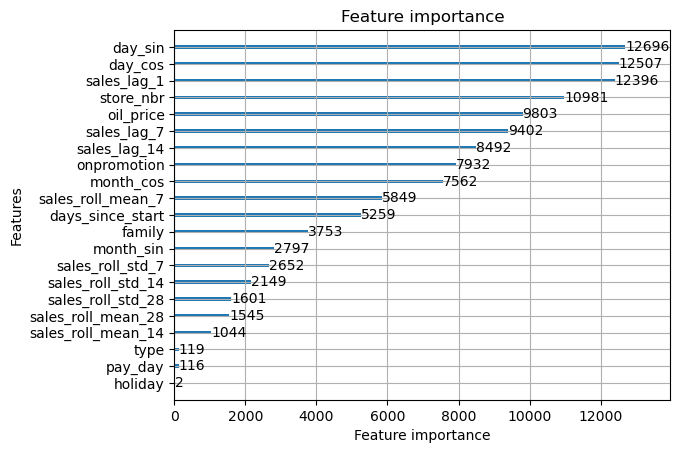

In [22]:
y_pred = final_model_lag.predict(X_val,num_iteration=final_model_lag.best_iteration)
rmse = np.sqrt(mean_squared_error(y_val,y_pred))
print("RMSE :",rmse)
lgb.plot_importance(final_model_lag,max_num_features=30)

In [23]:
print(final_model_lag.params)
print(model_lag.params)

{'num_leaves': 254, 'max_depth': 14, 'learning_rate': 0.007751305206355776, 'feature_fraction': 0.8892400023139403, 'bagging_fraction': 0.8555931119163103, 'bagging_freq': 2, 'min_data_in_leaf': 114, 'lambda_l1': 0.19191301023943697, 'lambda_l2': 2.44480184237154, 'objective': 'regression', 'metric': 'rmse', 'boosting_type': 'gbdt', 'device_type': 'cpu', 'seed': 20, 'num_iterations': 5000, 'categorical_column': [0, 1, 3, 4, 5]}
{'objective': 'regression', 'metric': 'rmse', 'boosting_type': 'gbdt', 'learning_rate': 0.05, 'num_leaves': 64, 'feature_fraction': 0.9, 'bagging_fraction': 0.8, 'bagging_freq': 5, 'verbose': -1, 'num_iterations': 2000, 'categorical_column': [0, 1, 3, 4, 5]}


In [26]:
results_df.sort_values(by=["rmse"],inplace=True)
results_df["distance"]=results_df.apply(lambda x :np.sqrt(mean_squared_error(x[9:],results_df.iloc[0,9:])),axis=1)
results_df["diff_rmse"]= results_df.apply(lambda x : x["rmse"]-results_df.iloc[0]["rmse"],axis=1)

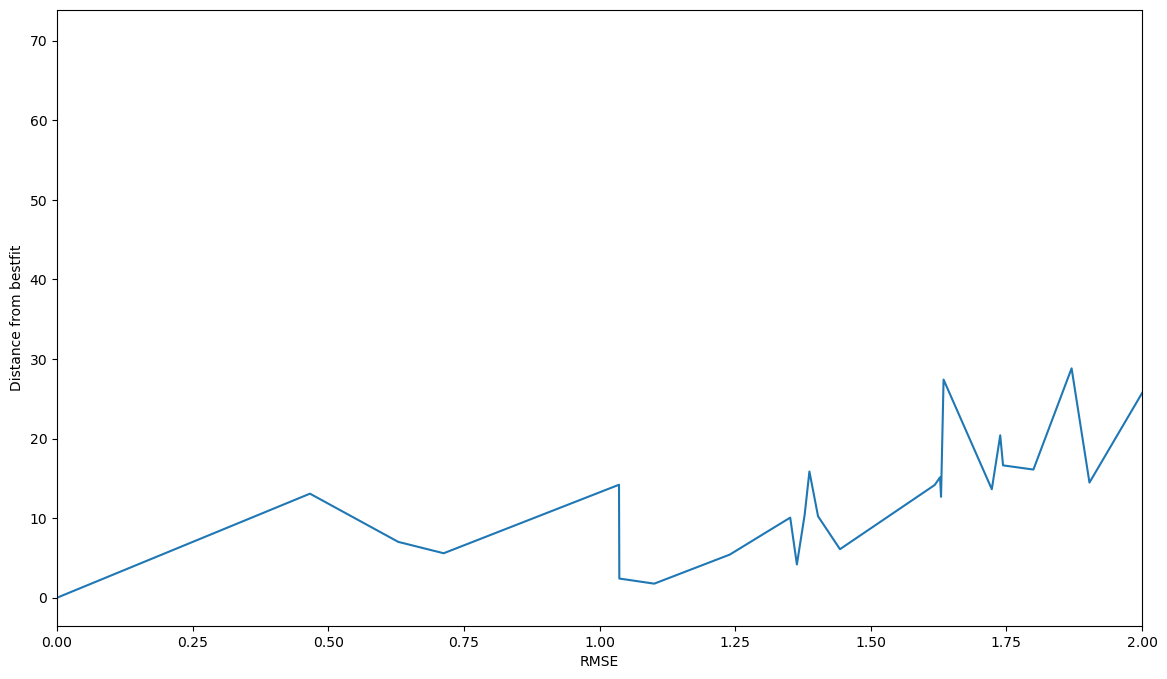

In [27]:
plt.figure(figsize=(14,8))
plt.plot(results_df["diff_rmse"],results_df["distance"])
plt.xlabel("RMSE")
plt.ylabel("Distance from bestfit")
plt.xlim(left=0,right =2)
plt.show()

In [30]:
results_df.iloc[:20,9:]

,num_leaves,max_depth,learning_rate,feature_fraction,bagging_fraction,bagging_freq,min_data_in_leaf,lambda_l1,lambda_l2,diff_rmse,distance
43,254,14,0.007751,0.889240,0.855593,2,114,0.191913,2.444802,0.000000,0.000000
21,231,15,0.014348,0.934818,0.971503,6,148,2.867905,3.172086,0.466235,13.076402
16,250,16,0.010137,0.848289,0.703079,6,93,4.017726,1.847397,0.628992,7.017224
23,237,14,0.015799,0.874880,0.887847,6,112,0.845636,3.996679,0.712733,5.588783
19,224,14,0.008572,0.938944,0.933848,6,147,2.849112,4.088801,1.035903,14.198046
41,247,14,0.011767,0.860882,0.820084,4,116,0.097470,2.350702,1.036485,2.410273
26,253,14,0.011449,0.861647,0.826827,4,119,0.073478,2.306617,1.100831,1.767669
48,254,15,0.007562,0.602391,0.977561,2,131,1.076444,3.595835,1.240099,5.419800
42,236,15,0.012511,0.821546,0.825955,5,140,0.477236,1.269851,1.351496,10.066250
40,247,16,0.019701,0.998250,0.764591,4,124,3.738072,4.313647,1.363796,4.182679


Here we can see the best model kind of prefer larger num_leaves and amx_depth which means we are looking at very complex models. There are prone to overfitting. SImpler models are always the best.

Lets further bring down the parameter range and increase the regularization coefficient ranges and check


In [34]:
trial_results2 = []
def objective_simple(trial):
    params = {
        "objective" : " regression",
        "metric" : "rmse",
        "boosting_type" : "gbdt",
        "seed" : 20,
        "num_leaves" : trial.suggest_int("num_leaves", 31, 128),
        "max_depth" : trial.suggest_int("max_depth", 3, 8),
        "learning_rate" : trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "feature_fraction" : trial.suggest_float("feature_fraction", 0.7,1.0),
        "bagging_fraction" : trial.suggest_float("bagging_fraction", 0.7,0.95),
        "bagging_freq" : trial.suggest_int("bagging_freq", 1, 10),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf",50,500),
        "lambda_l1" : trial.suggest_float("lambda_l1", 0.0, 10.0),
        "lambda_l2" : trial.suggest_float("lambda_l2",0.0,10.0)
    }

    model = lgb.train(
        params,
        lgb_lag_train,
        valid_sets=[lgb_lag_val],
        num_boost_round=5000,
        callbacks=[lgb.early_stopping(stopping_rounds=200)]
    )

    rmse = model.best_score["valid_0"]["rmse"]
    trial_results2.append({"trial":trial.number,"rmse":rmse,**params})
    return rmse

study_lag2 = optuna.create_study(direction="minimize")
study_lag2.optimize(objective_simple,n_trials=100)
results_df = pd.DataFrame(trial_results2)
print("Best fit hyper parameter \n",study_lag2.best_trial.params)
print("Best RMSE value :", study_lag2.best_trial.value)

[I 2025-08-16 11:02:55,464] A new study created in memory with name: no-name-0861d99b-d96c-4073-89e0-a845d49015fe


Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:03:05,699] Trial 0 finished with value: 231.0661955860175 and parameters: {'num_leaves': 42, 'max_depth': 4, 'learning_rate': 0.055349776747266925, 'feature_fraction': 0.8257310041305043, 'bagging_fraction': 0.9415795827295299, 'bagging_freq': 5, 'min_data_in_leaf': 89, 'lambda_l1': 2.134158231939961, 'lambda_l2': 9.166421248144111}. Best is trial 0 with value: 231.0661955860175.


Early stopping, best iteration is:
[282]	valid_0's rmse: 231.066
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:03:20,802] Trial 1 finished with value: 226.2287453534297 and parameters: {'num_leaves': 44, 'max_depth': 7, 'learning_rate': 0.016353460960710917, 'feature_fraction': 0.9552378445772929, 'bagging_fraction': 0.9116708922972694, 'bagging_freq': 3, 'min_data_in_leaf': 218, 'lambda_l1': 9.144210310366528, 'lambda_l2': 8.98360887327984}. Best is trial 1 with value: 226.2287453534297.


Early stopping, best iteration is:
[282]	valid_0's rmse: 226.229
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:03:28,394] Trial 2 finished with value: 225.20404001057258 and parameters: {'num_leaves': 39, 'max_depth': 7, 'learning_rate': 0.06745932286769454, 'feature_fraction': 0.8756460302184265, 'bagging_fraction': 0.7507419598926932, 'bagging_freq': 5, 'min_data_in_leaf': 250, 'lambda_l1': 8.081730453637114, 'lambda_l2': 3.4495466544265083}. Best is trial 2 with value: 225.20404001057258.


Early stopping, best iteration is:
[72]	valid_0's rmse: 225.204
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:03:37,745] Trial 3 finished with value: 224.51369083971215 and parameters: {'num_leaves': 66, 'max_depth': 8, 'learning_rate': 0.03948812906218481, 'feature_fraction': 0.9395854700790978, 'bagging_fraction': 0.8276260694221658, 'bagging_freq': 7, 'min_data_in_leaf': 86, 'lambda_l1': 1.6723332110877476, 'lambda_l2': 5.7031279170649025}. Best is trial 3 with value: 224.51369083971215.


Early stopping, best iteration is:
[104]	valid_0's rmse: 224.514
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:04:03,689] Trial 4 finished with value: 221.64090421409122 and parameters: {'num_leaves': 109, 'max_depth': 8, 'learning_rate': 0.011014615772911988, 'feature_fraction': 0.922378440181622, 'bagging_fraction': 0.8059497395518657, 'bagging_freq': 2, 'min_data_in_leaf': 108, 'lambda_l1': 3.8206271746173526, 'lambda_l2': 2.2262314368277636}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[364]	valid_0's rmse: 221.641
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:04:18,611] Trial 5 finished with value: 225.75133280042047 and parameters: {'num_leaves': 60, 'max_depth': 8, 'learning_rate': 0.011649740424124118, 'feature_fraction': 0.8072499738350668, 'bagging_fraction': 0.7658419811994518, 'bagging_freq': 1, 'min_data_in_leaf': 460, 'lambda_l1': 9.652988769706408, 'lambda_l2': 4.069153563952954}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[403]	valid_0's rmse: 225.751
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:04:29,496] Trial 6 finished with value: 226.19535725046222 and parameters: {'num_leaves': 68, 'max_depth': 7, 'learning_rate': 0.04343364724025167, 'feature_fraction': 0.9247050142641938, 'bagging_fraction': 0.8451547040334619, 'bagging_freq': 2, 'min_data_in_leaf': 485, 'lambda_l1': 2.7957406169030987, 'lambda_l2': 7.126101794205331}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[98]	valid_0's rmse: 226.195
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:04:38,818] Trial 7 finished with value: 224.26282803966225 and parameters: {'num_leaves': 112, 'max_depth': 7, 'learning_rate': 0.08260280971772421, 'feature_fraction': 0.7292042032784732, 'bagging_fraction': 0.9420288494059409, 'bagging_freq': 5, 'min_data_in_leaf': 178, 'lambda_l1': 2.545453685766227, 'lambda_l2': 3.7142845090623133}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[55]	valid_0's rmse: 224.263
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:04:58,810] Trial 8 finished with value: 226.73968974830188 and parameters: {'num_leaves': 116, 'max_depth': 5, 'learning_rate': 0.012161631458909779, 'feature_fraction': 0.7384060643225471, 'bagging_fraction': 0.7389276102512019, 'bagging_freq': 4, 'min_data_in_leaf': 124, 'lambda_l1': 6.040084282644856, 'lambda_l2': 1.0370557796656665}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[616]	valid_0's rmse: 226.74
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:05:09,929] Trial 9 finished with value: 225.19732826165225 and parameters: {'num_leaves': 101, 'max_depth': 6, 'learning_rate': 0.0356191194159098, 'feature_fraction': 0.8127143527344893, 'bagging_fraction': 0.9414436046226755, 'bagging_freq': 9, 'min_data_in_leaf': 186, 'lambda_l1': 4.97412684570937, 'lambda_l2': 3.149324773669714}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[144]	valid_0's rmse: 225.197
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:05:32,635] Trial 10 finished with value: 232.8114153852237 and parameters: {'num_leaves': 90, 'max_depth': 3, 'learning_rate': 0.021853389661277374, 'feature_fraction': 0.9870722107813867, 'bagging_fraction': 0.8702165242588612, 'bagging_freq': 10, 'min_data_in_leaf': 357, 'lambda_l1': 0.35658849314609053, 'lambda_l2': 0.06660157821658874}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[1270]	valid_0's rmse: 232.811
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:05:42,106] Trial 11 finished with value: 222.77721555269855 and parameters: {'num_leaves': 125, 'max_depth': 8, 'learning_rate': 0.0893953324833704, 'feature_fraction': 0.7052397486630045, 'bagging_fraction': 0.7937697471084327, 'bagging_freq': 7, 'min_data_in_leaf': 160, 'lambda_l1': 4.236586396444116, 'lambda_l2': 2.0954561346564784}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[49]	valid_0's rmse: 222.777
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:05:51,529] Trial 12 finished with value: 222.58982170696157 and parameters: {'num_leaves': 128, 'max_depth': 8, 'learning_rate': 0.09899001693334193, 'feature_fraction': 0.8822033018350105, 'bagging_fraction': 0.7931225007714126, 'bagging_freq': 7, 'min_data_in_leaf': 51, 'lambda_l1': 4.693041464702154, 'lambda_l2': 1.8114037792750315}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[39]	valid_0's rmse: 222.59
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:06:03,732] Trial 13 finished with value: 224.38397520368633 and parameters: {'num_leaves': 128, 'max_depth': 6, 'learning_rate': 0.02316305036791332, 'feature_fraction': 0.8887916963139195, 'bagging_fraction': 0.7120470998730567, 'bagging_freq': 7, 'min_data_in_leaf': 51, 'lambda_l1': 6.754932996628257, 'lambda_l2': 1.984093678694927}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[209]	valid_0's rmse: 224.384
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:06:18,310] Trial 14 finished with value: 222.891866646883 and parameters: {'num_leaves': 99, 'max_depth': 8, 'learning_rate': 0.02311770311143848, 'feature_fraction': 0.8911604607109193, 'bagging_fraction': 0.7965475145866747, 'bagging_freq': 8, 'min_data_in_leaf': 348, 'lambda_l1': 3.9030536988217497, 'lambda_l2': 5.397912757087508}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[184]	valid_0's rmse: 222.892
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:06:24,114] Trial 15 finished with value: 227.97294441640227 and parameters: {'num_leaves': 111, 'max_depth': 5, 'learning_rate': 0.05239541427501738, 'feature_fraction': 0.9971756653325481, 'bagging_fraction': 0.7964473346530204, 'bagging_freq': 1, 'min_data_in_leaf': 55, 'lambda_l1': 6.050544234664973, 'lambda_l2': 0.0715499247978233}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[136]	valid_0's rmse: 227.973
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:06:40,992] Trial 16 finished with value: 224.42959118844178 and parameters: {'num_leaves': 89, 'max_depth': 6, 'learning_rate': 0.016684834032323643, 'feature_fraction': 0.859427725434012, 'bagging_fraction': 0.8665351794047544, 'bagging_freq': 3, 'min_data_in_leaf': 304, 'lambda_l1': 3.955847961042744, 'lambda_l2': 1.9378180826170297}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[299]	valid_0's rmse: 224.43
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:06:54,233] Trial 17 finished with value: 222.90173132251 and parameters: {'num_leaves': 121, 'max_depth': 8, 'learning_rate': 0.029865277298169016, 'feature_fraction': 0.9121417769838673, 'bagging_fraction': 0.7767279959365128, 'bagging_freq': 6, 'min_data_in_leaf': 126, 'lambda_l1': 7.365514400892199, 'lambda_l2': 6.741631207724531}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[129]	valid_0's rmse: 222.902
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:07:13,208] Trial 18 finished with value: 222.48777715648077 and parameters: {'num_leaves': 104, 'max_depth': 7, 'learning_rate': 0.015126780143176737, 'feature_fraction': 0.7737161590853319, 'bagging_fraction': 0.8313438742007507, 'bagging_freq': 9, 'min_data_in_leaf': 128, 'lambda_l1': 0.6910661813713825, 'lambda_l2': 1.1594968867768545}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[302]	valid_0's rmse: 222.488
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:07:35,956] Trial 19 finished with value: 223.3453959406372 and parameters: {'num_leaves': 81, 'max_depth': 7, 'learning_rate': 0.010088474126120196, 'feature_fraction': 0.7747268935040635, 'bagging_fraction': 0.8869398488414665, 'bagging_freq': 10, 'min_data_in_leaf': 278, 'lambda_l1': 0.11824258440494018, 'lambda_l2': 0.8901172030797619}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[440]	valid_0's rmse: 223.345
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:07:53,375] Trial 20 finished with value: 224.25568641762916 and parameters: {'num_leaves': 103, 'max_depth': 6, 'learning_rate': 0.014424569347343454, 'feature_fraction': 0.7634329041186838, 'bagging_fraction': 0.830830191046484, 'bagging_freq': 9, 'min_data_in_leaf': 134, 'lambda_l1': 1.0771353861774347, 'lambda_l2': 4.488782972954683}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[369]	valid_0's rmse: 224.256
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:08:10,091] Trial 21 finished with value: 222.46505356835146 and parameters: {'num_leaves': 107, 'max_depth': 8, 'learning_rate': 0.018512735860303376, 'feature_fraction': 0.9671565767083798, 'bagging_fraction': 0.8155387883314972, 'bagging_freq': 8, 'min_data_in_leaf': 90, 'lambda_l1': 3.3139203486851523, 'lambda_l2': 2.5093736897756296}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[223]	valid_0's rmse: 222.465
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:08:27,815] Trial 22 finished with value: 223.3333089755874 and parameters: {'num_leaves': 91, 'max_depth': 7, 'learning_rate': 0.017965789774923933, 'feature_fraction': 0.9613999616411313, 'bagging_fraction': 0.8171478887846793, 'bagging_freq': 9, 'min_data_in_leaf': 108, 'lambda_l1': 3.1382118701359896, 'lambda_l2': 2.7312859003173977}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[286]	valid_0's rmse: 223.333
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:08:48,050] Trial 23 finished with value: 224.03636006827264 and parameters: {'num_leaves': 106, 'max_depth': 8, 'learning_rate': 0.013529589138095608, 'feature_fraction': 0.974397717213746, 'bagging_fraction': 0.8557356959419282, 'bagging_freq': 8, 'min_data_in_leaf': 199, 'lambda_l1': 1.399093803136009, 'lambda_l2': 1.3773519172853046}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[309]	valid_0's rmse: 224.036
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:09:11,235] Trial 24 finished with value: 224.45227854519763 and parameters: {'num_leaves': 80, 'max_depth': 7, 'learning_rate': 0.010202759254358198, 'feature_fraction': 0.9193752763753925, 'bagging_fraction': 0.8147463480283867, 'bagging_freq': 8, 'min_data_in_leaf': 152, 'lambda_l1': 3.4581232952512866, 'lambda_l2': 2.82191947719835}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[479]	valid_0's rmse: 224.452
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:09:27,065] Trial 25 finished with value: 224.03231463696255 and parameters: {'num_leaves': 96, 'max_depth': 8, 'learning_rate': 0.019519101048263092, 'feature_fraction': 0.8311878419440776, 'bagging_fraction': 0.8891015081028826, 'bagging_freq': 6, 'min_data_in_leaf': 229, 'lambda_l1': 0.9261312548405067, 'lambda_l2': 0.6015036672456926}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[207]	valid_0's rmse: 224.032
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:09:40,662] Trial 26 finished with value: 223.59273195438175 and parameters: {'num_leaves': 118, 'max_depth': 7, 'learning_rate': 0.02834786092048034, 'feature_fraction': 0.7805467614255687, 'bagging_fraction': 0.8498606478281192, 'bagging_freq': 10, 'min_data_in_leaf': 91, 'lambda_l1': 2.0748778417425053, 'lambda_l2': 2.6273586148364827}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[156]	valid_0's rmse: 223.593
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:10:00,271] Trial 27 finished with value: 224.24778616645997 and parameters: {'num_leaves': 108, 'max_depth': 8, 'learning_rate': 0.014656919707820406, 'feature_fraction': 0.9435930321121834, 'bagging_fraction': 0.8105089400141768, 'bagging_freq': 4, 'min_data_in_leaf': 156, 'lambda_l1': 5.490465878751596, 'lambda_l2': 4.455768925795971}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[279]	valid_0's rmse: 224.248
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:10:24,879] Trial 28 finished with value: 232.84574850756601 and parameters: {'num_leaves': 95, 'max_depth': 3, 'learning_rate': 0.012688130291163181, 'feature_fraction': 0.9022753864449099, 'bagging_fraction': 0.7744115961831133, 'bagging_freq': 9, 'min_data_in_leaf': 419, 'lambda_l1': 3.3901575270964694, 'lambda_l2': 1.3907407512151695}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[1466]	valid_0's rmse: 232.846
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:10:38,124] Trial 29 finished with value: 229.84029642150585 and parameters: {'num_leaves': 85, 'max_depth': 4, 'learning_rate': 0.02610380887553938, 'feature_fraction': 0.8545340912326428, 'bagging_fraction': 0.7251665101934869, 'bagging_freq': 2, 'min_data_in_leaf': 99, 'lambda_l1': 2.226152832507782, 'lambda_l2': 9.13220327246667}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[399]	valid_0's rmse: 229.84
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:10:54,415] Trial 30 finished with value: 226.45505115112718 and parameters: {'num_leaves': 73, 'max_depth': 5, 'learning_rate': 0.020272671939812515, 'feature_fraction': 0.8349569167401618, 'bagging_fraction': 0.8389493016926053, 'bagging_freq': 6, 'min_data_in_leaf': 79, 'lambda_l1': 4.585486917593412, 'lambda_l2': 6.256550439430873}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[425]	valid_0's rmse: 226.455
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:11:04,524] Trial 31 finished with value: 224.90728027056682 and parameters: {'num_leaves': 123, 'max_depth': 8, 'learning_rate': 0.06887987878433847, 'feature_fraction': 0.8767202468259173, 'bagging_fraction': 0.7881139911243253, 'bagging_freq': 8, 'min_data_in_leaf': 50, 'lambda_l1': 5.198213132225758, 'lambda_l2': 2.031599338631158}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[54]	valid_0's rmse: 224.907
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:11:22,738] Trial 32 finished with value: 222.02519000198646 and parameters: {'num_leaves': 109, 'max_depth': 8, 'learning_rate': 0.015781609563108798, 'feature_fraction': 0.9659907613438395, 'bagging_fraction': 0.8078721286559861, 'bagging_freq': 7, 'min_data_in_leaf': 80, 'lambda_l1': 4.6374685780827996, 'lambda_l2': 1.5117937171373477}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[265]	valid_0's rmse: 222.025
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:11:41,334] Trial 33 finished with value: 224.0882451027349 and parameters: {'num_leaves': 105, 'max_depth': 7, 'learning_rate': 0.015455455078625788, 'feature_fraction': 0.9652900409806724, 'bagging_fraction': 0.7595936990465061, 'bagging_freq': 8, 'min_data_in_leaf': 129, 'lambda_l1': 3.729112050174096, 'lambda_l2': 8.120335151334753}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[304]	valid_0's rmse: 224.088
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:11:52,348] Trial 34 finished with value: 226.83274457198854 and parameters: {'num_leaves': 33, 'max_depth': 8, 'learning_rate': 0.01818438063663486, 'feature_fraction': 0.9425936711946536, 'bagging_fraction': 0.8071485638525674, 'bagging_freq': 4, 'min_data_in_leaf': 79, 'lambda_l1': 5.704996495899072, 'lambda_l2': 0.7636859431785429}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[276]	valid_0's rmse: 226.833
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:12:10,165] Trial 35 finished with value: 225.55430262547955 and parameters: {'num_leaves': 52, 'max_depth': 7, 'learning_rate': 0.011427002613091056, 'feature_fraction': 0.977157360126259, 'bagging_fraction': 0.8291060111831422, 'bagging_freq': 7, 'min_data_in_leaf': 217, 'lambda_l1': 1.6602857763960017, 'lambda_l2': 3.674256800277526}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[401]	valid_0's rmse: 225.554
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:12:27,603] Trial 36 finished with value: 222.4348072363811 and parameters: {'num_leaves': 114, 'max_depth': 8, 'learning_rate': 0.016266385995786954, 'feature_fraction': 0.9339872568627611, 'bagging_fraction': 0.7465672024986388, 'bagging_freq': 9, 'min_data_in_leaf': 105, 'lambda_l1': 6.752825183430265, 'lambda_l2': 2.55169835420418}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[243]	valid_0's rmse: 222.435
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:12:44,391] Trial 37 finished with value: 222.65586788875555 and parameters: {'num_leaves': 113, 'max_depth': 8, 'learning_rate': 0.017265610719877998, 'feature_fraction': 0.9352345847973683, 'bagging_fraction': 0.7420819059877591, 'bagging_freq': 5, 'min_data_in_leaf': 77, 'lambda_l1': 7.518607130430004, 'lambda_l2': 2.514262625315925}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[224]	valid_0's rmse: 222.656
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:13:06,626] Trial 38 finished with value: 222.04522027007013 and parameters: {'num_leaves': 117, 'max_depth': 8, 'learning_rate': 0.011422336192114545, 'feature_fraction': 0.95276152550745, 'bagging_fraction': 0.702619918921527, 'bagging_freq': 6, 'min_data_in_leaf': 107, 'lambda_l1': 8.817303746173959, 'lambda_l2': 3.308407406628974}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[354]	valid_0's rmse: 222.045
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:13:33,790] Trial 39 finished with value: 230.7487625313711 and parameters: {'num_leaves': 117, 'max_depth': 4, 'learning_rate': 0.01148025010015026, 'feature_fraction': 0.9288567394309682, 'bagging_fraction': 0.7057749770815755, 'bagging_freq': 3, 'min_data_in_leaf': 162, 'lambda_l1': 9.026460719891945, 'lambda_l2': 9.886470797279788}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[1080]	valid_0's rmse: 230.749
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:13:53,894] Trial 40 finished with value: 223.2596576031604 and parameters: {'num_leaves': 114, 'max_depth': 8, 'learning_rate': 0.013113596349823826, 'feature_fraction': 0.9519348497716995, 'bagging_fraction': 0.719222709687078, 'bagging_freq': 6, 'min_data_in_leaf': 192, 'lambda_l1': 9.113688059521062, 'lambda_l2': 3.316185717325284}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[306]	valid_0's rmse: 223.26
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:14:18,086] Trial 41 finished with value: 222.50621956114006 and parameters: {'num_leaves': 120, 'max_depth': 8, 'learning_rate': 0.010935042961908122, 'feature_fraction': 0.9851552487389237, 'bagging_fraction': 0.7325594762696844, 'bagging_freq': 7, 'min_data_in_leaf': 106, 'lambda_l1': 8.350831099885305, 'lambda_l2': 3.9829000047227106}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[389]	valid_0's rmse: 222.506
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:14:37,810] Trial 42 finished with value: 222.2174805047943 and parameters: {'num_leaves': 110, 'max_depth': 8, 'learning_rate': 0.013016963468586131, 'feature_fraction': 0.9531219559030015, 'bagging_fraction': 0.7462619817073706, 'bagging_freq': 5, 'min_data_in_leaf': 108, 'lambda_l1': 9.7567823820617, 'lambda_l2': 3.1433697076916065}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[295]	valid_0's rmse: 222.217
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:14:58,537] Trial 43 finished with value: 223.50777360593153 and parameters: {'num_leaves': 110, 'max_depth': 8, 'learning_rate': 0.012834901848340718, 'feature_fraction': 0.9124060170858346, 'bagging_fraction': 0.70025012104635, 'bagging_freq': 5, 'min_data_in_leaf': 144, 'lambda_l1': 9.962635685655766, 'lambda_l2': 4.7302262113088345}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[328]	valid_0's rmse: 223.508
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:15:19,353] Trial 44 finished with value: 222.95804956929916 and parameters: {'num_leaves': 99, 'max_depth': 8, 'learning_rate': 0.013465607828050173, 'feature_fraction': 0.9491354322174266, 'bagging_fraction': 0.7459728465792517, 'bagging_freq': 2, 'min_data_in_leaf': 173, 'lambda_l1': 8.455215001642433, 'lambda_l2': 3.166444365080938}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[300]	valid_0's rmse: 222.958
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:15:44,268] Trial 45 finished with value: 221.84218500888562 and parameters: {'num_leaves': 116, 'max_depth': 7, 'learning_rate': 0.010940454468450891, 'feature_fraction': 0.9318946068451102, 'bagging_fraction': 0.7604313793973205, 'bagging_freq': 4, 'min_data_in_leaf': 112, 'lambda_l1': 9.541616419602379, 'lambda_l2': 3.933972597985293}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[413]	valid_0's rmse: 221.842
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:16:09,671] Trial 46 finished with value: 223.05570153649913 and parameters: {'num_leaves': 123, 'max_depth': 7, 'learning_rate': 0.010063618763537377, 'feature_fraction': 0.9574252166963868, 'bagging_fraction': 0.7641645098626959, 'bagging_freq': 4, 'min_data_in_leaf': 68, 'lambda_l1': 9.667949633053155, 'lambda_l2': 3.9566304049297076}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[412]	valid_0's rmse: 223.056
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:16:34,157] Trial 47 finished with value: 223.45431960539239 and parameters: {'num_leaves': 117, 'max_depth': 7, 'learning_rate': 0.011842124320797176, 'feature_fraction': 0.9991513028321123, 'bagging_fraction': 0.778516894451243, 'bagging_freq': 2, 'min_data_in_leaf': 112, 'lambda_l1': 8.923539105322781, 'lambda_l2': 5.2480187701617105}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[371]	valid_0's rmse: 223.454
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:16:56,651] Trial 48 finished with value: 224.72968917297837 and parameters: {'num_leaves': 128, 'max_depth': 6, 'learning_rate': 0.01094506183507949, 'feature_fraction': 0.9017779053604651, 'bagging_fraction': 0.7555512623806052, 'bagging_freq': 3, 'min_data_in_leaf': 252, 'lambda_l1': 9.51476155295148, 'lambda_l2': 3.5596568503742483}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[490]	valid_0's rmse: 224.73
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:17:04,905] Trial 49 finished with value: 223.1282003417358 and parameters: {'num_leaves': 110, 'max_depth': 7, 'learning_rate': 0.03842844941990051, 'feature_fraction': 0.9855489676546894, 'bagging_fraction': 0.7291300858615645, 'bagging_freq': 1, 'min_data_in_leaf': 70, 'lambda_l1': 7.897262593960031, 'lambda_l2': 1.7410515065615324}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[122]	valid_0's rmse: 223.128
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:17:21,353] Trial 50 finished with value: 224.979338699837 and parameters: {'num_leaves': 74, 'max_depth': 8, 'learning_rate': 0.0141843783384714, 'feature_fraction': 0.9267421405745709, 'bagging_fraction': 0.7178637875406649, 'bagging_freq': 5, 'min_data_in_leaf': 172, 'lambda_l1': 8.707578370670232, 'lambda_l2': 3.074349302161081}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[295]	valid_0's rmse: 224.979
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:17:39,694] Trial 51 finished with value: 222.11902878134399 and parameters: {'num_leaves': 114, 'max_depth': 8, 'learning_rate': 0.016038488253151975, 'feature_fraction': 0.9341098784150913, 'bagging_fraction': 0.7522665561570944, 'bagging_freq': 5, 'min_data_in_leaf': 115, 'lambda_l1': 6.838185069537525, 'lambda_l2': 2.3342559551216224}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[253]	valid_0's rmse: 222.119
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:18:01,017] Trial 52 finished with value: 222.06917068903465 and parameters: {'num_leaves': 120, 'max_depth': 8, 'learning_rate': 0.012019664319230355, 'feature_fraction': 0.9133389732491504, 'bagging_fraction': 0.7751266011200157, 'bagging_freq': 5, 'min_data_in_leaf': 118, 'lambda_l1': 6.798681357324475, 'lambda_l2': 2.2329064908183662}. Best is trial 4 with value: 221.64090421409122.


Early stopping, best iteration is:
[309]	valid_0's rmse: 222.069
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:18:24,791] Trial 53 finished with value: 221.63673289758503 and parameters: {'num_leaves': 125, 'max_depth': 8, 'learning_rate': 0.012062410036106934, 'feature_fraction': 0.9103197959317831, 'bagging_fraction': 0.7684672115084601, 'bagging_freq': 4, 'min_data_in_leaf': 121, 'lambda_l1': 6.609838199861028, 'lambda_l2': 2.230492919348887}. Best is trial 53 with value: 221.63673289758503.


Early stopping, best iteration is:
[355]	valid_0's rmse: 221.637
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:18:49,092] Trial 54 finished with value: 222.14537022140885 and parameters: {'num_leaves': 125, 'max_depth': 8, 'learning_rate': 0.012247506413853072, 'feature_fraction': 0.8982335643641128, 'bagging_fraction': 0.7878811978664052, 'bagging_freq': 4, 'min_data_in_leaf': 134, 'lambda_l1': 6.265249203013065, 'lambda_l2': 1.601170729472057}. Best is trial 53 with value: 221.63673289758503.


Early stopping, best iteration is:
[357]	valid_0's rmse: 222.145
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:19:13,424] Trial 55 finished with value: 223.68956193481483 and parameters: {'num_leaves': 121, 'max_depth': 7, 'learning_rate': 0.010654457302631731, 'feature_fraction': 0.8648910731083432, 'bagging_fraction': 0.7706236868759894, 'bagging_freq': 6, 'min_data_in_leaf': 141, 'lambda_l1': 4.384485866357886, 'lambda_l2': 2.1673428590072605}. Best is trial 53 with value: 221.63673289758503.


Early stopping, best iteration is:
[417]	valid_0's rmse: 223.69
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:19:25,517] Trial 56 finished with value: 222.49934039402942 and parameters: {'num_leaves': 125, 'max_depth': 8, 'learning_rate': 0.04636589156543125, 'feature_fraction': 0.9161113694877063, 'bagging_fraction': 0.7642354226064897, 'bagging_freq': 3, 'min_data_in_leaf': 65, 'lambda_l1': 5.019442343637596, 'lambda_l2': 4.218325297844889}. Best is trial 53 with value: 221.63673289758503.


Early stopping, best iteration is:
[86]	valid_0's rmse: 222.499
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:19:51,527] Trial 57 finished with value: 222.89347230085073 and parameters: {'num_leaves': 119, 'max_depth': 7, 'learning_rate': 0.011876357276703485, 'feature_fraction': 0.8670821998021089, 'bagging_fraction': 0.8055428750811052, 'bagging_freq': 4, 'min_data_in_leaf': 89, 'lambda_l1': 7.929085481451903, 'lambda_l2': 0.5183886857040685}. Best is trial 53 with value: 221.63673289758503.


Early stopping, best iteration is:
[368]	valid_0's rmse: 222.893
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:20:08,231] Trial 58 finished with value: 224.9783213189995 and parameters: {'num_leaves': 56, 'max_depth': 6, 'learning_rate': 0.014459512387969898, 'feature_fraction': 0.8879949448913037, 'bagging_fraction': 0.7828169329253158, 'bagging_freq': 6, 'min_data_in_leaf': 327, 'lambda_l1': 7.32491591614148, 'lambda_l2': 1.1892494081205789}. Best is trial 53 with value: 221.63673289758503.


Early stopping, best iteration is:
[360]	valid_0's rmse: 224.978
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:20:32,299] Trial 59 finished with value: 223.12525075841646 and parameters: {'num_leaves': 101, 'max_depth': 8, 'learning_rate': 0.010860701287728708, 'feature_fraction': 0.9201432090019345, 'bagging_fraction': 0.7974269597026366, 'bagging_freq': 7, 'min_data_in_leaf': 418, 'lambda_l1': 9.38624473082551, 'lambda_l2': 1.6096513820074778}. Best is trial 53 with value: 221.63673289758503.


Early stopping, best iteration is:
[412]	valid_0's rmse: 223.125
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:20:55,642] Trial 60 finished with value: 223.40927361856174 and parameters: {'num_leaves': 124, 'max_depth': 7, 'learning_rate': 0.011780041198617103, 'feature_fraction': 0.9095317760168606, 'bagging_fraction': 0.8215513439014004, 'bagging_freq': 4, 'min_data_in_leaf': 205, 'lambda_l1': 2.832103715358467, 'lambda_l2': 0.31504367523041776}. Best is trial 53 with value: 221.63673289758503.


Early stopping, best iteration is:
[367]	valid_0's rmse: 223.409
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:21:14,998] Trial 61 finished with value: 222.95209462913573 and parameters: {'num_leaves': 112, 'max_depth': 8, 'learning_rate': 0.01586392387605944, 'feature_fraction': 0.9411339446699047, 'bagging_fraction': 0.735303865923714, 'bagging_freq': 5, 'min_data_in_leaf': 115, 'lambda_l1': 6.706565322806422, 'lambda_l2': 2.2381957782057387}. Best is trial 53 with value: 221.63673289758503.


Early stopping, best iteration is:
[260]	valid_0's rmse: 222.952
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:21:35,782] Trial 62 finished with value: 222.3086307777026 and parameters: {'num_leaves': 115, 'max_depth': 8, 'learning_rate': 0.014054335638798005, 'feature_fraction': 0.9727017959626302, 'bagging_fraction': 0.7561902762800811, 'bagging_freq': 5, 'min_data_in_leaf': 120, 'lambda_l1': 6.123734637139, 'lambda_l2': 2.873876246018554}. Best is trial 53 with value: 221.63673289758503.


Early stopping, best iteration is:
[297]	valid_0's rmse: 222.309
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:21:50,821] Trial 63 finished with value: 221.54783765203152 and parameters: {'num_leaves': 107, 'max_depth': 8, 'learning_rate': 0.020960873306480287, 'feature_fraction': 0.9310590020796337, 'bagging_fraction': 0.772013214940846, 'bagging_freq': 6, 'min_data_in_leaf': 92, 'lambda_l1': 7.014650434270534, 'lambda_l2': 2.296113818948547}. Best is trial 63 with value: 221.54783765203152.


Early stopping, best iteration is:
[190]	valid_0's rmse: 221.548
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:22:07,373] Trial 64 finished with value: 221.03753066532119 and parameters: {'num_leaves': 128, 'max_depth': 8, 'learning_rate': 0.020920746788397393, 'feature_fraction': 0.9228570992990912, 'bagging_fraction': 0.781425419142919, 'bagging_freq': 6, 'min_data_in_leaf': 89, 'lambda_l1': 5.566383346954089, 'lambda_l2': 3.461827154924672}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[188]	valid_0's rmse: 221.038
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:22:21,481] Trial 65 finished with value: 223.23519010797025 and parameters: {'num_leaves': 107, 'max_depth': 8, 'learning_rate': 0.02511625155391252, 'feature_fraction': 0.9255142328229429, 'bagging_fraction': 0.7974704846735611, 'bagging_freq': 6, 'min_data_in_leaf': 93, 'lambda_l1': 5.752745388293341, 'lambda_l2': 3.431864051925006}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[159]	valid_0's rmse: 223.235
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:22:33,785] Trial 66 finished with value: 224.22178253944145 and parameters: {'num_leaves': 103, 'max_depth': 8, 'learning_rate': 0.030754228608604113, 'feature_fraction': 0.9612511623051541, 'bagging_fraction': 0.8031067940520592, 'bagging_freq': 7, 'min_data_in_leaf': 57, 'lambda_l1': 5.281283653015381, 'lambda_l2': 4.919117189510129}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[127]	valid_0's rmse: 224.222
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:22:45,976] Trial 67 finished with value: 222.39333140538915 and parameters: {'num_leaves': 128, 'max_depth': 8, 'learning_rate': 0.01937096587609276, 'feature_fraction': 0.9470211584614707, 'bagging_fraction': 0.7864488145834815, 'bagging_freq': 1, 'min_data_in_leaf': 146, 'lambda_l1': 4.226829959472612, 'lambda_l2': 3.832048292259679}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[207]	valid_0's rmse: 222.393
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:23:00,905] Trial 68 finished with value: 222.78886481051222 and parameters: {'num_leaves': 96, 'max_depth': 8, 'learning_rate': 0.020847732559802684, 'feature_fraction': 0.8946578758990074, 'bagging_fraction': 0.7655919270346438, 'bagging_freq': 6, 'min_data_in_leaf': 93, 'lambda_l1': 4.858262844236275, 'lambda_l2': 4.314467181844426}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[193]	valid_0's rmse: 222.789
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:23:12,192] Trial 69 finished with value: 226.60467983453907 and parameters: {'num_leaves': 123, 'max_depth': 5, 'learning_rate': 0.03325313555632817, 'feature_fraction': 0.8421375877412881, 'bagging_fraction': 0.8353244235394024, 'bagging_freq': 7, 'min_data_in_leaf': 78, 'lambda_l1': 6.416087399608156, 'lambda_l2': 2.925018141651534}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[247]	valid_0's rmse: 226.605
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:23:29,040] Trial 70 finished with value: 223.45882132545566 and parameters: {'num_leaves': 118, 'max_depth': 7, 'learning_rate': 0.021309230804240468, 'feature_fraction': 0.8058708301298476, 'bagging_fraction': 0.9249625646806275, 'bagging_freq': 6, 'min_data_in_leaf': 165, 'lambda_l1': 5.846232462581938, 'lambda_l2': 5.962859751067056}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[221]	valid_0's rmse: 223.459
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:23:51,068] Trial 71 finished with value: 222.4523633972631 and parameters: {'num_leaves': 120, 'max_depth': 8, 'learning_rate': 0.012394335447368876, 'feature_fraction': 0.8836852256265005, 'bagging_fraction': 0.7754194624130021, 'bagging_freq': 6, 'min_data_in_leaf': 127, 'lambda_l1': 7.494633052009242, 'lambda_l2': 1.8502913854039997}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[332]	valid_0's rmse: 222.452
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:24:06,870] Trial 72 finished with value: 223.8227306278581 and parameters: {'num_leaves': 125, 'max_depth': 8, 'learning_rate': 0.023184002334775213, 'feature_fraction': 0.9101276532332151, 'bagging_fraction': 0.7822112181313909, 'bagging_freq': 7, 'min_data_in_leaf': 61, 'lambda_l1': 7.109356310412166, 'lambda_l2': 2.3431456945462985}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[176]	valid_0's rmse: 223.823
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:24:24,352] Trial 73 finished with value: 223.06954793031792 and parameters: {'num_leaves': 108, 'max_depth': 8, 'learning_rate': 0.017350107773996683, 'feature_fraction': 0.9349471610204297, 'bagging_fraction': 0.770272093334059, 'bagging_freq': 5, 'min_data_in_leaf': 97, 'lambda_l1': 5.39274416229498, 'lambda_l2': 1.365953837989882}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[244]	valid_0's rmse: 223.07
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:24:48,534] Trial 74 finished with value: 222.59167751066786 and parameters: {'num_leaves': 121, 'max_depth': 8, 'learning_rate': 0.01069696345071031, 'feature_fraction': 0.9226503284722417, 'bagging_fraction': 0.7921098214381178, 'bagging_freq': 3, 'min_data_in_leaf': 85, 'lambda_l1': 6.384709171133942, 'lambda_l2': 2.641198976606161}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[358]	valid_0's rmse: 222.592
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:25:08,194] Trial 75 finished with value: 222.6289109677176 and parameters: {'num_leaves': 116, 'max_depth': 8, 'learning_rate': 0.015123963594534273, 'feature_fraction': 0.9040851889969959, 'bagging_fraction': 0.817203577885613, 'bagging_freq': 4, 'min_data_in_leaf': 126, 'lambda_l1': 7.71562041236523, 'lambda_l2': 3.4833754578579983}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[272]	valid_0's rmse: 222.629
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:25:28,612] Trial 76 finished with value: 223.67915600438627 and parameters: {'num_leaves': 128, 'max_depth': 7, 'learning_rate': 0.01353501212903684, 'feature_fraction': 0.9690491967252438, 'bagging_fraction': 0.8005566209074718, 'bagging_freq': 6, 'min_data_in_leaf': 103, 'lambda_l1': 8.270567141420273, 'lambda_l2': 1.0153893915380943}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[310]	valid_0's rmse: 223.679
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:25:53,903] Trial 77 finished with value: 222.6847354315165 and parameters: {'num_leaves': 112, 'max_depth': 8, 'learning_rate': 0.010034552008378127, 'feature_fraction': 0.9433654373097736, 'bagging_fraction': 0.8225968892781869, 'bagging_freq': 5, 'min_data_in_leaf': 152, 'lambda_l1': 7.010903384583524, 'lambda_l2': 2.070711252434762}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[410]	valid_0's rmse: 222.685
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:26:16,817] Trial 78 finished with value: 224.6441775395438 and parameters: {'num_leaves': 92, 'max_depth': 8, 'learning_rate': 0.011301846940033696, 'feature_fraction': 0.9605095846385499, 'bagging_fraction': 0.7800911145318821, 'bagging_freq': 7, 'min_data_in_leaf': 500, 'lambda_l1': 3.7340481632147484, 'lambda_l2': 2.8027390063488853}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[404]	valid_0's rmse: 224.644
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:26:39,458] Trial 79 finished with value: 223.56541220819864 and parameters: {'num_leaves': 100, 'max_depth': 8, 'learning_rate': 0.012654050482534207, 'feature_fraction': 0.929785775429067, 'bagging_fraction': 0.809466971606538, 'bagging_freq': 2, 'min_data_in_leaf': 185, 'lambda_l1': 4.5997435613567035, 'lambda_l2': 4.6286665884666265}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[318]	valid_0's rmse: 223.565
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:26:53,928] Trial 80 finished with value: 224.12956814704245 and parameters: {'num_leaves': 117, 'max_depth': 7, 'learning_rate': 0.027053504529648845, 'feature_fraction': 0.9806468671897415, 'bagging_fraction': 0.7596895237395965, 'bagging_freq': 6, 'min_data_in_leaf': 141, 'lambda_l1': 6.5381925945695505, 'lambda_l2': 3.2098734245319345}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[180]	valid_0's rmse: 224.13
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:27:11,672] Trial 81 finished with value: 222.6708305421657 and parameters: {'num_leaves': 115, 'max_depth': 8, 'learning_rate': 0.016901095375607956, 'feature_fraction': 0.93711511615033, 'bagging_fraction': 0.7496418226242701, 'bagging_freq': 5, 'min_data_in_leaf': 121, 'lambda_l1': 7.032114119036557, 'lambda_l2': 2.4492257605753918}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[227]	valid_0's rmse: 222.671
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:27:27,334] Trial 82 finished with value: 221.61943771914738 and parameters: {'num_leaves': 109, 'max_depth': 8, 'learning_rate': 0.0233087725822039, 'feature_fraction': 0.9530868446940864, 'bagging_fraction': 0.7699405273554496, 'bagging_freq': 5, 'min_data_in_leaf': 114, 'lambda_l1': 6.033742240995459, 'lambda_l2': 2.2732614053970286}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[188]	valid_0's rmse: 221.619
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:27:41,352] Trial 83 finished with value: 222.5543310471631 and parameters: {'num_leaves': 105, 'max_depth': 8, 'learning_rate': 0.02454198624549252, 'feature_fraction': 0.953156152506914, 'bagging_fraction': 0.7704111877172006, 'bagging_freq': 4, 'min_data_in_leaf': 73, 'lambda_l1': 5.599842963161056, 'lambda_l2': 1.9208061347004484}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[153]	valid_0's rmse: 222.554
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:27:57,209] Trial 84 finished with value: 221.3665851359368 and parameters: {'num_leaves': 108, 'max_depth': 8, 'learning_rate': 0.02226460207606139, 'feature_fraction': 0.9139432046535865, 'bagging_fraction': 0.7919883216846687, 'bagging_freq': 3, 'min_data_in_leaf': 103, 'lambda_l1': 5.975479012758482, 'lambda_l2': 1.4104108216468974}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[183]	valid_0's rmse: 221.367
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:28:12,934] Trial 85 finished with value: 221.89942355437847 and parameters: {'num_leaves': 110, 'max_depth': 8, 'learning_rate': 0.021813872489008426, 'feature_fraction': 0.989625445547395, 'bagging_fraction': 0.7386460223946152, 'bagging_freq': 3, 'min_data_in_leaf': 83, 'lambda_l1': 6.002580964251917, 'lambda_l2': 1.5820155003170335}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[185]	valid_0's rmse: 221.899
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:28:27,976] Trial 86 finished with value: 223.6721019993716 and parameters: {'num_leaves': 103, 'max_depth': 8, 'learning_rate': 0.02251000578957351, 'feature_fraction': 0.995168475839136, 'bagging_fraction': 0.7404562838914672, 'bagging_freq': 3, 'min_data_in_leaf': 85, 'lambda_l1': 5.960228683314755, 'lambda_l2': 1.4689376702560502}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[177]	valid_0's rmse: 223.672
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:28:42,886] Trial 87 finished with value: 222.62183040492613 and parameters: {'num_leaves': 110, 'max_depth': 8, 'learning_rate': 0.028114574008881205, 'feature_fraction': 0.978218390839472, 'bagging_fraction': 0.7924348161480314, 'bagging_freq': 2, 'min_data_in_leaf': 98, 'lambda_l1': 5.04565179075652, 'lambda_l2': 0.8864430393426749}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[136]	valid_0's rmse: 222.622
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:29:00,018] Trial 88 finished with value: 223.65087900947407 and parameters: {'num_leaves': 107, 'max_depth': 7, 'learning_rate': 0.019178449700825002, 'feature_fraction': 0.991671823359297, 'bagging_fraction': 0.7854549883105445, 'bagging_freq': 3, 'min_data_in_leaf': 61, 'lambda_l1': 4.013475979976068, 'lambda_l2': 1.2450407131197156}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[222]	valid_0's rmse: 223.651
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:29:17,348] Trial 89 finished with value: 221.81573152716277 and parameters: {'num_leaves': 102, 'max_depth': 8, 'learning_rate': 0.02355987271790774, 'feature_fraction': 0.9669131472089371, 'bagging_fraction': 0.7586097161137386, 'bagging_freq': 2, 'min_data_in_leaf': 50, 'lambda_l1': 6.160360460572919, 'lambda_l2': 1.7261936857210343}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[181]	valid_0's rmse: 221.816
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:29:32,617] Trial 90 finished with value: 223.19553217103143 and parameters: {'num_leaves': 94, 'max_depth': 8, 'learning_rate': 0.023457083053907632, 'feature_fraction': 0.9070511212991055, 'bagging_fraction': 0.7602766785069289, 'bagging_freq': 2, 'min_data_in_leaf': 55, 'lambda_l1': 6.207558231146941, 'lambda_l2': 1.6968825081974424}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[179]	valid_0's rmse: 223.196
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:29:47,512] Trial 91 finished with value: 222.95208254760848 and parameters: {'num_leaves': 98, 'max_depth': 8, 'learning_rate': 0.020722627290530697, 'feature_fraction': 0.96435945243778, 'bagging_fraction': 0.7562575040573254, 'bagging_freq': 3, 'min_data_in_leaf': 79, 'lambda_l1': 5.640883348827139, 'lambda_l2': 1.8342488478730445}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[185]	valid_0's rmse: 222.952
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:30:02,431] Trial 92 finished with value: 223.08866082542002 and parameters: {'num_leaves': 102, 'max_depth': 8, 'learning_rate': 0.024832001469900604, 'feature_fraction': 0.9718312224941053, 'bagging_fraction': 0.7681995048297773, 'bagging_freq': 2, 'min_data_in_leaf': 50, 'lambda_l1': 5.99431857973868, 'lambda_l2': 1.4865863199285285}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[163]	valid_0's rmse: 223.089
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:30:13,365] Trial 93 finished with value: 223.19529533337086 and parameters: {'num_leaves': 105, 'max_depth': 8, 'learning_rate': 0.02211229957828088, 'feature_fraction': 0.988243410482106, 'bagging_fraction': 0.7916809214836787, 'bagging_freq': 1, 'min_data_in_leaf': 69, 'lambda_l1': 4.816320040628895, 'lambda_l2': 0.6834581228807574}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[187]	valid_0's rmse: 223.195
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:30:29,564] Trial 94 finished with value: 221.41724642569565 and parameters: {'num_leaves': 111, 'max_depth': 8, 'learning_rate': 0.018668503790228625, 'feature_fraction': 0.9169451778926384, 'bagging_fraction': 0.7770883462093193, 'bagging_freq': 4, 'min_data_in_leaf': 83, 'lambda_l1': 5.422757123471797, 'lambda_l2': 1.1078827223109093}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[204]	valid_0's rmse: 221.417
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:30:46,462] Trial 95 finished with value: 221.97995521241455 and parameters: {'num_leaves': 87, 'max_depth': 8, 'learning_rate': 0.018600133507657466, 'feature_fraction': 0.9296867720325956, 'bagging_fraction': 0.7502034780766363, 'bagging_freq': 3, 'min_data_in_leaf': 106, 'lambda_l1': 5.360485557178632, 'lambda_l2': 1.0331153849649353}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[252]	valid_0's rmse: 221.98
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:31:03,040] Trial 96 finished with value: 222.7219412301642 and parameters: {'num_leaves': 111, 'max_depth': 8, 'learning_rate': 0.019968209299276583, 'feature_fraction': 0.9179491538622971, 'bagging_fraction': 0.7746644752172198, 'bagging_freq': 4, 'min_data_in_leaf': 136, 'lambda_l1': 6.478583632375316, 'lambda_l2': 0.48348668246928495}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[195]	valid_0's rmse: 222.722
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:31:17,301] Trial 97 finished with value: 221.76519102087457 and parameters: {'num_leaves': 107, 'max_depth': 8, 'learning_rate': 0.023863353941873344, 'feature_fraction': 0.7261750028524929, 'bagging_fraction': 0.779519223767151, 'bagging_freq': 4, 'min_data_in_leaf': 87, 'lambda_l1': 5.867912991848917, 'lambda_l2': 0.29620678017645075}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[156]	valid_0's rmse: 221.765
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:31:30,064] Trial 98 finished with value: 224.47707389190205 and parameters: {'num_leaves': 113, 'max_depth': 6, 'learning_rate': 0.02672149050363364, 'feature_fraction': 0.7221727988031268, 'bagging_fraction': 0.7802458920675054, 'bagging_freq': 4, 'min_data_in_leaf': 95, 'lambda_l1': 5.57163111266785, 'lambda_l2': 0.26026356702939685}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[208]	valid_0's rmse: 224.477
Training until validation scores don't improve for 200 rounds


[I 2025-08-16 11:31:41,021] Trial 99 finished with value: 227.72905276992137 and parameters: {'num_leaves': 98, 'max_depth': 5, 'learning_rate': 0.029038424949319384, 'feature_fraction': 0.8930550725303922, 'bagging_fraction': 0.7653784786165307, 'bagging_freq': 4, 'min_data_in_leaf': 287, 'lambda_l1': 6.608122214429022, 'lambda_l2': 0.05547616866074717}. Best is trial 64 with value: 221.03753066532119.


Early stopping, best iteration is:
[243]	valid_0's rmse: 227.729
Best fit hyper parameter 
 {'num_leaves': 128, 'max_depth': 8, 'learning_rate': 0.020920746788397393, 'feature_fraction': 0.9228570992990912, 'bagging_fraction': 0.781425419142919, 'bagging_freq': 6, 'min_data_in_leaf': 89, 'lambda_l1': 5.566383346954089, 'lambda_l2': 3.461827154924672}
Best RMSE value : 221.03753066532119
